In [ ]:
import os
import ast
import json
import random
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import meteostat as ms 
import geopandas as gpd
import matplotlib as mpl
import scipy.stats as st
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import ConnectionPatch

from pyspark.sql import types as T
from pyspark.sql import functions as F
from shapely.geometry import LineString

from pyspark.sql import SparkSession

from scipy import stats
from linearmodels.panel import PanelOLS

from GDynaDist import Graphs4Distance
from datetime import datetime

from src.data.data_sampling import get_random_sample, mapping_for_embedding
from src.data.weather import get_weather_data_ByNode

from src.analysis.centralities import compute_centralities, get_ratio_matrix_for_centralities, find_top_bottom_quartile_districts, map_closeness
from src.analysis.hotspots import iterative_lorenz_hotspots
from src.analysis.radiation_model import radiation_model, common_part_of_commuters

In [13]:
# Create Spark session
spark = SparkSession.builder \
    .appName("Data analysis") \
    .master("local[40]") \
    .config("spark.driver.memory", "30g") \
    .config("spark.executor.memory", "60g") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/22 16:31:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Study area: Valencia (417 nodes)

(np.float64(-1111073.870635),
 np.float64(1233502.700735),
 np.float64(3045775.638770001),
 np.float64(4945595.11923))

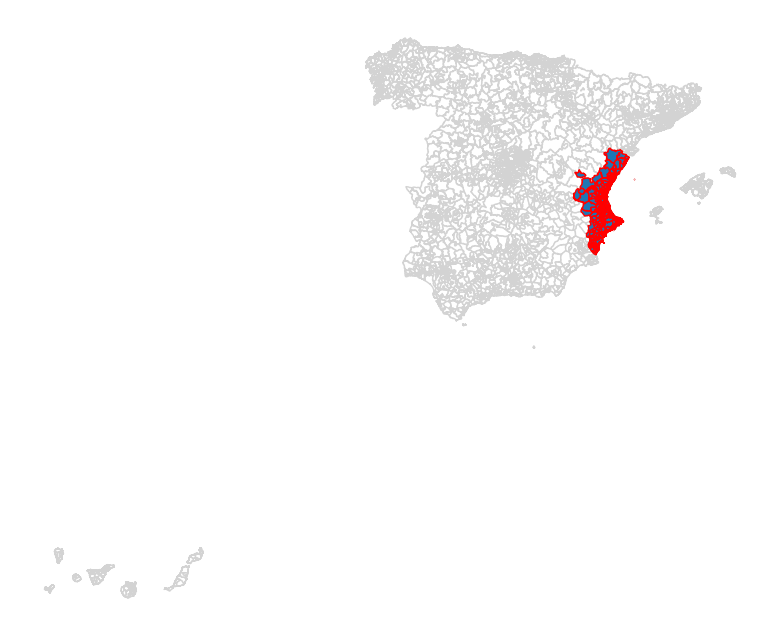

In [8]:
gdf_areas = gpd.read_file('/home/daltamirano/data/zonification/zonificacion_distritos.shp')
gdf_nodes = gpd.read_file("/home/daltamirano/data/zonification/zonificacion_distritos_centroides.shp")
poblacion = pd.read_csv('/home/daltamirano/data/zonification/poblacion.csv', delimiter='|')
SC_districts = list(poblacion[(poblacion.provincia == 3) | (poblacion.provincia == 12) | (poblacion.provincia == 46)]['distrito'].unique())
gdf_nodes = gdf_nodes[gdf_nodes['ID'].isin(set(SC_districts))]
gdf_SC = gdf_areas[gdf_areas['ID'].isin(set(SC_districts))]

district_names = pd.read_csv('/home/daltamirano/data/zonification/nombres_distritos.csv', delimiter='|')

gdf_DANA = gpd.read_file('/home/daltamirano/data/zonification/00_DANA2024.csv')
codes = np.array(gdf_DANA['cod_ine_mun'])

affected_by_DANA = gdf_areas[gdf_areas['ID'].astype(str).str.startswith(tuple(codes))]

abroad_areas_df = pd.read_csv('/home/daltamirano/data/zonification/areas_out_Spain.csv')
abroad_areas = list(abroad_areas_df['ID'])

fig, ax = plt.subplots(1, 1, figsize=(18, 8))
gdf_areas[gdf_areas['ID'].isin(list(set(gdf_areas['ID']) - set(abroad_areas)))].plot(ax=ax, edgecolor='lightgray', facecolor='white')
gdf_areas[gdf_areas['ID'].isin(set(SC_districts))].plot(ax=ax, edgecolor='red')
ax.axis('off')

In [14]:
# read the dictionary after the pre processing

with open("/home/daltamirano/data/dictionary_areas_ACTUAL_df.json", "r", encoding="utf-8") as f:
    dict_SC = json.load(f)

dict_SC_inv = {value:key for key, value in dict_SC.items()}

# read the dataset
df_study_case = spark.read.parquet('/home/daltamirano/data/data_refined/')
df_study_case = df_study_case.filter(F.col('total_trips') != 0)

## Computing actual distance

In [ ]:
distances_contribution = []
nodes = np.arange(len(dict_SC))

for day in [row.fecha for row in df_study_case.select('fecha').distinct().collect()]:
    df_to_study_daily = df_study_case.filter(F.col("fecha") == day)

    # Split the dataset into man and women
    df_woman = df_to_study_daily.filter(F.col('sexo') == 'mujer')
    df_man = df_to_study_daily.filter(F.col('sexo') == 'hombre')

    # Select the origin, destination, time and weight columns (global transition matrix) and rewrite to i, j, t and τ
    pd_df_woman = df_woman.select(F.col('origin_id').alias('i'), F.col('destination_id').alias('j'), F.col('periodo').alias('t'), F.col('total_trips').alias('w')).toPandas()
    pd_df_man = df_man.select(F.col('origin_id').alias('i'), F.col('destination_id').alias('j'), F.col('periodo').alias('t'), F.col('total_trips').alias('w')).toPandas()

    Data = Graphs4Distance(verbose=0)
    # Loading the dataset
    Data.LoadDataset(pd_df_man, 'graph_man', nodes=nodes) 
    Data.LoadDataset(pd_df_woman, 'graph_woman', nodes=nodes)

    dist = Data.GetDistance('graph_man', 'graph_woman', distance_type = 'matched', node_mapping = 'Same')

    X = Data.graphs['graph_woman'].X
    Y = Data.graphs['graph_man'].X

    adj_matrix_node_distances = ((X @ X.T) - (Y @ Y.T))**2
    node_i_contribution = np.sum(adj_matrix_node_distances, axis = 0)/np.sum(adj_matrix_node_distances)

    distances_contribution.append([day, dist, node_i_contribution])
    
distances_and_contribution = pd.DataFrame(distances_contribution, columns=["day", "distance", "node_contribution"])
distances_and_contribution.to_csv("/data/big/davidaltamirano/SC_Valencia_comunidad/actual_distance_and_node_contribution_last.csv")

# actual_distance_and_node_contribution_last --> no links with zero trips

count    119.000000
mean       8.187717
std        1.954798
min        6.108328
25%        7.166978
50%        7.697280
75%        8.658865
max       22.327817
Name: distance, dtype: float64


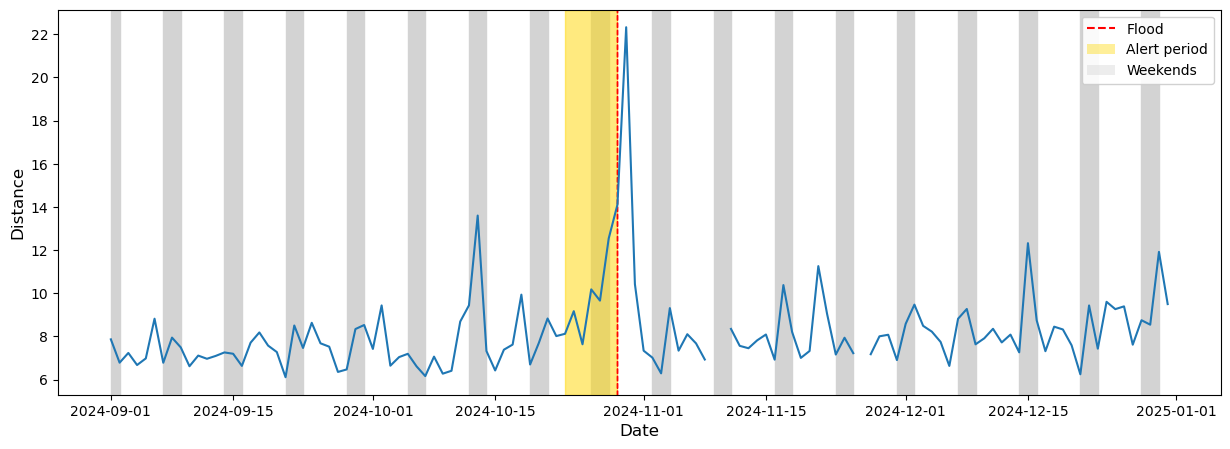

In [ ]:
full_range = pd.date_range(start='2024-09-01', end='2024-12-31', freq='D')

actual_distances = pd.read_csv('/home/daltamirano/data/actual_distance_and_node_contribution_last.csv')
actual_distances['day'] = pd.to_datetime(actual_distances['day'], format='%Y%m%d')
actual_distances = actual_distances.sort_values(by='day').reset_index(drop=True)

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(actual_distances.groupby('day')['distance'].mean().reindex(full_range))
plt.ylabel('Distance', fontsize=12)
plt.xlabel('Date', fontsize=12)

for date in full_range:
    if date.weekday() >= 5: 
        plt.axvspan(date, date + pd.Timedelta(days=1), color='lightgrey', alpha=1)
        
plt.axvspan('2024-10-23', '2024-10-29', color='gold', linestyle='-', alpha=0.5)
plt.axvspan('2024-10-29', '2024-10-29', color='red', linestyle='--', alpha=1)

legend_elements = [Line2D([0], [0], color='red', linewidth=1.5, linestyle='--', label='Flood'),
                   mpatches.Patch(facecolor='gold', alpha=0.4, label='Alert period'),
                   mpatches.Patch(facecolor='lightgrey',  alpha=0.4, label='Weekends'),
                   ]

plt.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

plt.savefig('/images/distance_signal.png', dpi=300, bbox_inches='tight')

print(actual_distances['distance'].describe())

## Computing null model distances

In [ ]:
original_file_name = f'/data/big/davidaltamirano/results/study_case/null_distances_rnddays.csv'

ex_dates = [20240915, 20240929, 
            20241003, 20241021,
            20241104, 20241113, 20241127, 
            20241211, 20201228]

nodes = np.arange(len(dict_SC))

for day in ex_dates:        
    df_to_study_daily = df_study_case.filter(F.col("fecha") == day)
    df_to_study_daily = df_to_study_daily.replace(['hombre', 'mujer'], 'NA', subset=['sexo'])
    df_to_study_daily = df_to_study_daily.groupBy('periodo', 'origin_id', 'destination_id').agg(F.sum('total_trips').alias('total_trips'))
            
    for i in range(100):
        df_W, df_M = get_random_sample(df_to_study_daily, 'total_trips') 

        # Select the origin, destination, time and weight columns (global transition matrix) and rewrite to i, j, t and w
        pd_df_woman = df_W.select(F.col('origin_id').alias('i'), F.col('destination_id').alias('j'), F.col('periodo').alias('t'), F.col('total_trips').alias('w')).toPandas()
        pd_df_man = df_M.select(F.col('origin_id').alias('i'), F.col('destination_id').alias('j'), F.col('periodo').alias('t'), F.col('total_trips').alias('w')).toPandas()

        n_trips_W = np.sum(pd_df_woman['w'])
        n_trips_M = np.sum(pd_df_man['w'])
        
        Data = Graphs4Distance(verbose=0)
        # Loading the dataset
        Data.LoadDataset(pd_df_man, 'graph_man', nodes=nodes)
        Data.LoadDataset(pd_df_woman, 'graph_woman', nodes=nodes)
        
        dist = Data.GetDistance('graph_man', 'graph_woman', distance_type = 'matched', node_mapping = 'Same')
        
        # Save the results
        if not os.path.exists(original_file_name):
            with open(original_file_name, "w") as f:
                f.write("day,i,n_trips_W,n_trips_M,distance\n")

        with open(original_file_name, 'a') as f:
            f.write(f"{day},{i},{n_trips_W},{n_trips_M},{dist}\n")

IndexError: list index out of range

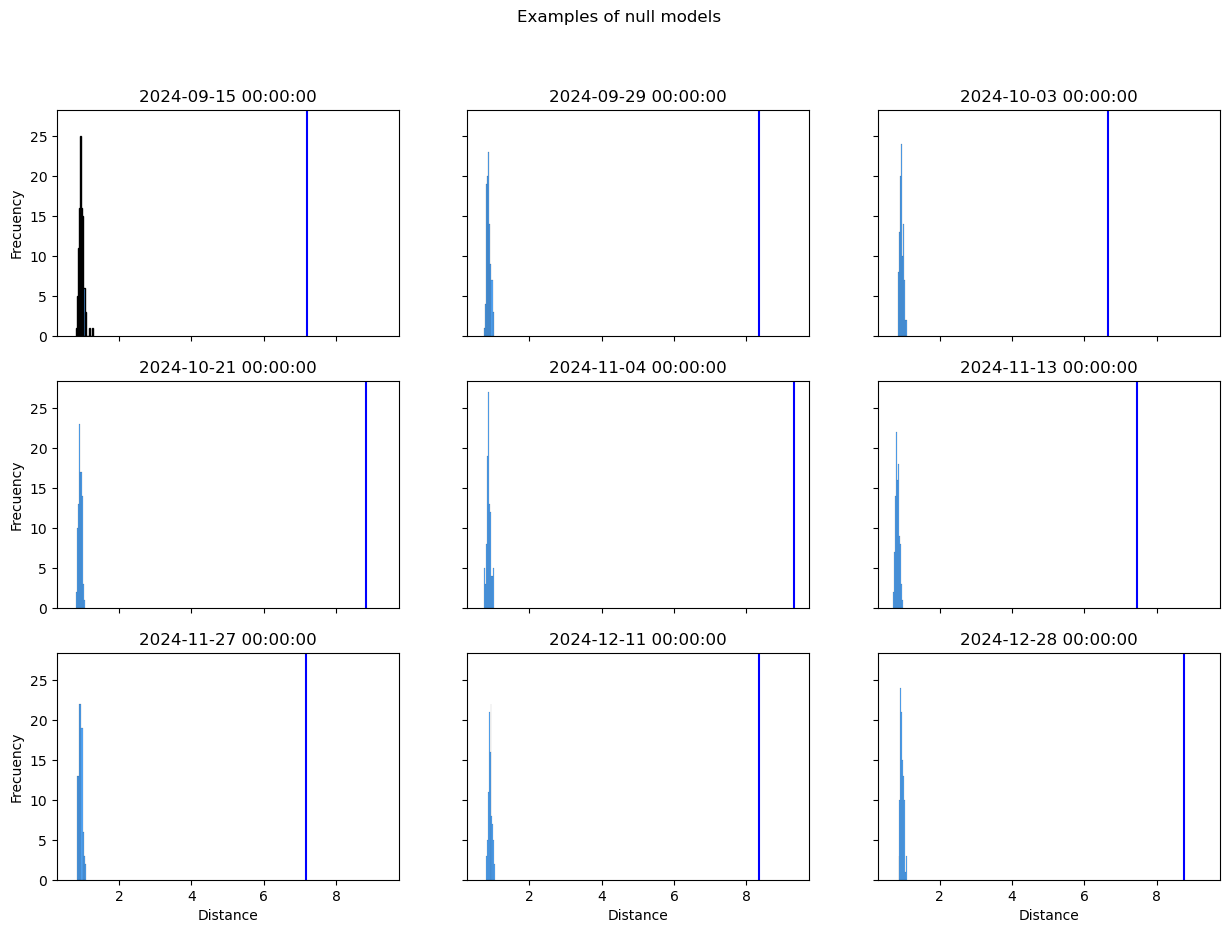

In [ ]:
null_distances = pd.read_csv('/data/big/davidaltamirano/results/study_case/null_distances_rnddays.csv')
null_distances['day'] = pd.to_datetime(null_distances['day'], format='%Y%m%d')

dates_examples = null_distances.sort_values(by='day')['day'].unique()

fig, axs = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
axs = axs.flatten()
fig.suptitle('Examples of null models')

for idx, day in enumerate(dates_examples):
    ax = axs[idx]
    sns.histplot(null_distances[null_distances['day'] == day]['distance'], color='dodgerblue', kde=False, ax=ax)
    ax.axvline(x = np.mean(actual_distances[actual_distances['day'] == day]['distance']), color ='blue', label = "Original distance")
    ax.set_title(day)
    ax.set_xlabel('Distance')
    ax.set_ylabel('Frecuency')

plt.savefig('/images/null_model_distances.png', dpi=300, bbox_inches='tight')

In [32]:
z_scores = []
for day in dates_examples:
    dist_real = np.mean(actual_distances[actual_distances['day'] == day]['distance'])
    dist_null = np.mean(null_distances[null_distances['day'] == day]['distance'])
    std_null = np.std(null_distances[null_distances['day'] == day]['distance'])

    z_score = (dist_real - dist_null)/(std_null)
    z_scores.append([day, z_score])
    
z_scores = pd.DataFrame(z_scores, columns=['date', 'z_score'])
z_scores['day'] = z_scores['date'].dt.strftime('%a')
z_scores

,date,z_score,day
0,2024-09-15,97.995870,Sun
1,2024-09-29,140.756564,Sun
2,2024-10-03,115.508115,Thu
3,2024-10-21,155.837969,Mon
4,2024-11-04,135.456042,Mon
5,2024-11-13,98.332238,Wed
6,2024-11-27,113.802546,Wed
7,2024-12-11,111.678186,Wed
8,2024-12-28,159.333466,Sat


## Identifying the node's contribution to the actual distance

In [70]:
node_contrib = pd.DataFrame(actual_distances['node_contribution'].apply(lambda x: np.fromstring(x.strip('[]'), sep=' ')).tolist())
node_contrib_abs = node_contrib.mul(np.square(actual_distances['distance']), axis=0)
node_contrib_rel = node_contrib

daily_contribution_abs = pd.concat([actual_distances[['day']].reset_index(drop=True), node_contrib_abs], axis=1).groupby('day').mean()
daily_contribution_abs = daily_contribution_abs.reset_index()

daily_contribution_rel = pd.concat([actual_distances[['day']].reset_index(drop=True), node_contrib_rel], axis=1).groupby('day').mean()
daily_contribution_rel = daily_contribution_rel.reset_index()

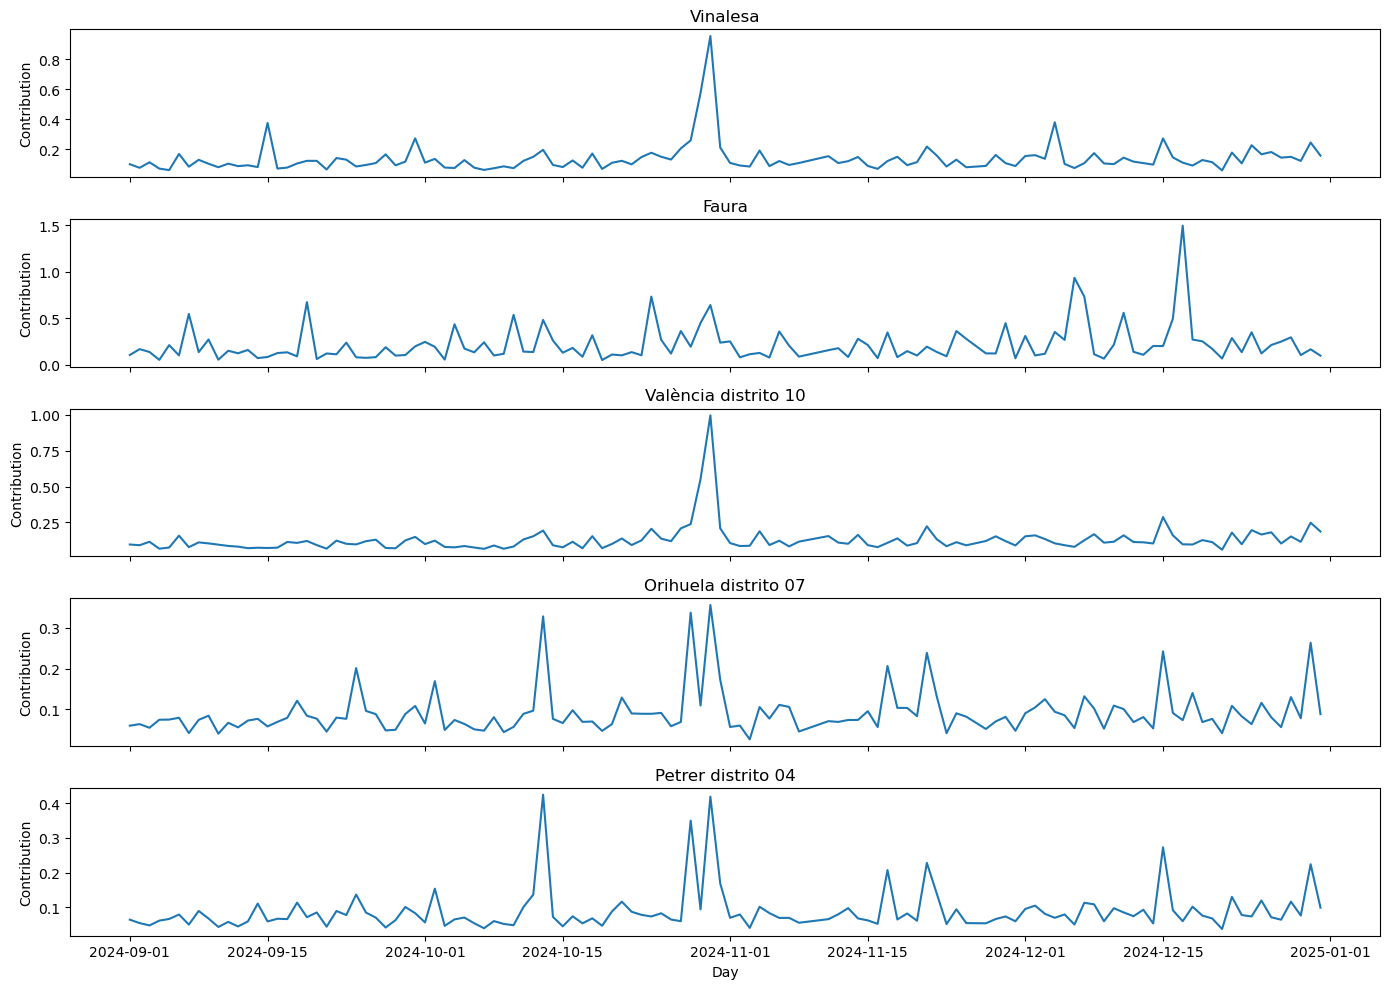

<Figure size 640x480 with 0 Axes>

In [73]:
id_name_dict = dict(zip(district_names["ID"], district_names["name"]))

node_cols = daily_contribution_abs.columns.drop("day")

selected_nodes = np.random.choice(node_cols, size=5, replace=False)
selected_nodes

fig, axes = plt.subplots(
    nrows=5, ncols=1,
    figsize=(14,10),
    sharex=True
)

for ax, node in zip(axes, selected_nodes):
    ax.plot(daily_contribution_abs["day"], daily_contribution_abs[node])
    ax.set_title(id_name_dict.get(dict_SC_inv.get(node), f"Node {dict_SC_inv.get(node)}"))
    ax.set_ylabel("Contribution")

axes[-1].set_xlabel("Day")
plt.tight_layout()
plt.show()

plt.savefig('example_nodes_contribution.png', dpi=300, bbox_inches='tight')

## Compute centralities

In [ ]:
# Script to compute the centralities
# The output is stored in a .csv file, which is called in the next cell

"""
genders = ['hombre', 'mujer']

daily_centrality = []

for gender in genders:
    for day in [row.fecha for row in df_study_case.select('fecha').distinct().collect()]:        
        df_to_study_daily = df_study_case.filter((F.col("fecha") == day) & (F.col("sexo") == gender))
        daily_edges = df_to_study_daily.groupBy('origin_id', 'destination_id').agg(F.sum('total_trips').alias('total_trips'))
        # Select the origin, destination and weight columns
        edges_pd = daily_edges.select(F.col('origin_id').alias('src'), F.col('destination_id').alias('dst'), F.col('total_trips').alias('weight')).toPandas()

        G = nx.DiGraph()
        # Adding the links to the network
        for _, row in edges_pd.iterrows():
            G.add_edge(row["src"], row["dst"], weight=row["weight"])

        stats = compute_centralities(G)
        
        daily_centrality.append([gender, day, stats['strength'], stats['betweenness'], stats['closeness']])
        
centralities = pd.DataFrame(daily_centrality, columns=['gender', 'day', 'strength', 'betweenness', 'closeness'])
centralities.to_csv("/data/big/davidaltamirano/SC_Valencia_comunidad/centralities_by_gender.csv")
"""

In [75]:
centralities = pd.read_csv('/data/big/davidaltamirano/SC_Valencia_comunidad/centralities_by_gender.csv')

daily_closeness_ratio, daily_closeness_women, daily_closeness_men = get_ratio_matrix_for_centralities(centralities, net_metric='closeness')

In [76]:
clo = daily_closeness_men.loc["2024-09-01"].rename(index=dict_SC_inv)
clo_df = gdf_SC.merge(clo, left_on='ID', right_on=clo.index)
clo_df = clo_df.rename(columns={clo_df.columns[-1]: 'day'})

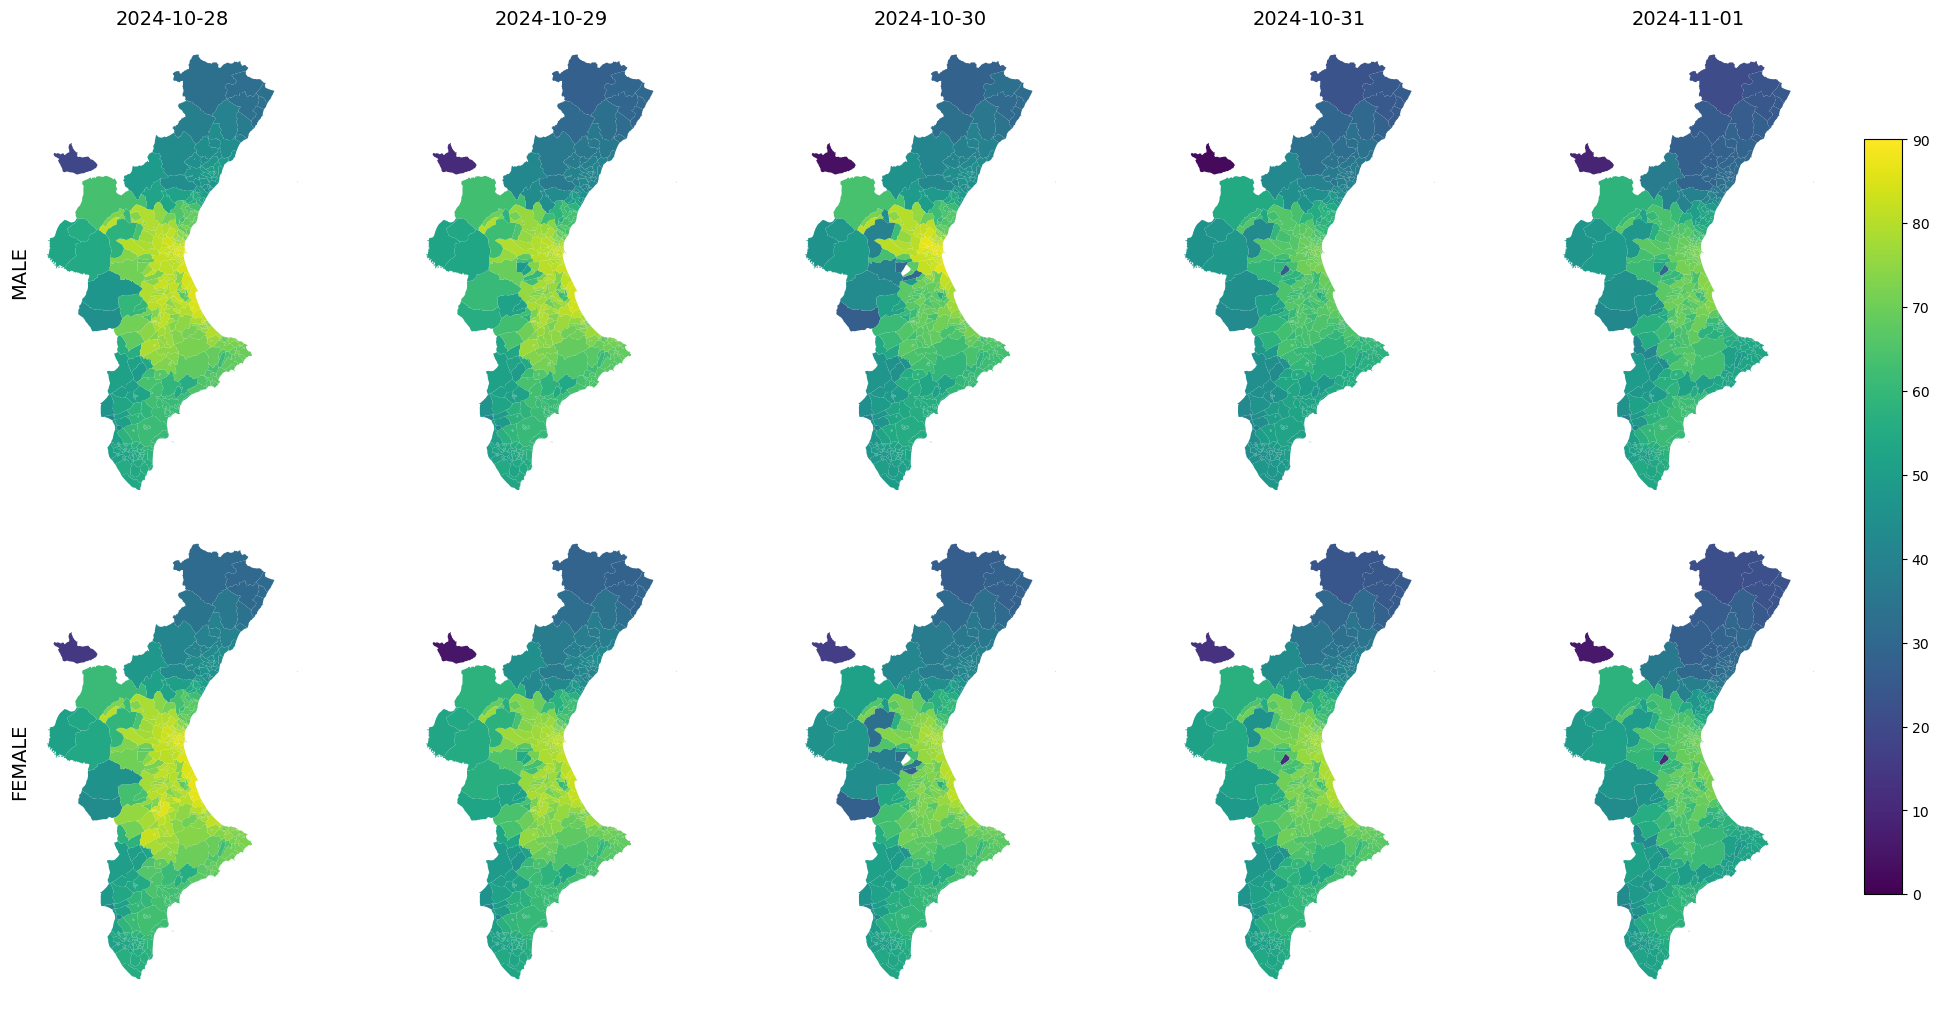

In [81]:
camp = 'viridis'

dates = ["2024-10-28", "2024-10-29", "2024-10-30", "2024-10-31", "2024-11-01"]

fig, axes = plt.subplots(2, 5, figsize=(20, 10), constrained_layout=True)

for i, dat in enumerate(dates):
    clo = daily_closeness_men.loc[dat].rename(index=dict_SC_inv)
    clo_df = gdf_SC.merge(clo, left_on='ID', right_on=clo.index)
    clo_gdf = clo_df.rename(columns={clo_df.columns[-1]: 'day'})

    clo_gdf.plot(ax=axes[0,i], 
                    column="day", 
                    cmap=camp,
                    vmin=0,
                    vmax=90,
                    legend=False)
    axes[0,i].set_xticks([])
    axes[0,i].set_yticks([])
    axes[0,i].set_frame_on(False)
    axes[0,i].set_title(f"{dat}", fontsize=14)

for j, dat in enumerate(dates):
    clo = daily_closeness_women.loc[dat].rename(index=dict_SC_inv)
    clo_df = gdf_SC.merge(clo, left_on='ID', right_on=clo.index)
    clo_gdf = clo_df.rename(columns={clo_df.columns[-1]: 'day'})

    clo_gdf.plot(ax=axes[1,j], 
                    column="day", 
                    cmap=camp,
                    vmin=0,
                    vmax=90,
                    legend=False)
    axes[1,j].set_xticks([])
    axes[1,j].set_yticks([])
    axes[1,j].set_frame_on(False)

axes[0,0].set_ylabel("MALE", fontsize=14)
axes[1,0].set_ylabel("FEMALE", fontsize=14)



norm = mpl.colors.Normalize(vmin=0, vmax=90)
sm = mpl.cm.ScalarMappable(cmap=camp, norm=norm)
sm._A = []  # necesario para matplotlib

cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
#cbar.set_label(trip_kind)

## Export and Filter of METEO data

In [ ]:
# Script to extract weather data using Meteostats tool
# The output is stored in a .csv file, which is called later on in the notebook

"""
gdf_weather = gdf_SC.to_crs(epsg=4326)
gdf_weather["lon"] = gdf_weather.centroid.x
gdf_weather["lat"] = gdf_weather.centroid.y
gdf_weather = gdf_weather.drop('geometry', axis=1)

gdf_weather = gdf_weather[gdf_weather['ID'].isin(SC_districts)].reset_index(drop=True)
all_nodes = gdf_weather[['ID', 'lat', 'lon']].to_dict('records')

start = datetime(2024, 9, 1)
end = datetime(2024, 12, 31)


weather_dfs = []

for _, row in gdf_weather.iterrows():
    df_area_weather = get_weather_data_ByNode(row, start, end, all_nodes)

    #if df_area_weather is not None:
    weather_dfs.append(df_area_weather)

df_weather = pd.concat(weather_dfs, ignore_index=True)

df_weather.to_csv("/data/big/davidaltamirano/SC_Valencia_comunidad/weatherIDW.csv")
"""

## Export and Filter of Income Data

In [5]:
income_spain = pd.read_csv('/data/big/davidaltamirano/incomeDistrictsSpain.csv', delimiter=';')
income_spain = income_spain[(income_spain['Periodo'] == 2023) & (income_spain['Indicadores de renta media'] == 'Renta neta media por persona')]
income_spain[['distrito_ID', 'distrito_name']] = income_spain['Distritos'].str.split(' ' , n=1, expand=True)
income_spain.dropna(subset=['distrito_ID'], inplace=True)

In [ ]:
gdf_names = pd.read_csv('/data/big/davidaltamirano/nombres_distritos.csv', delimiter='|')

def filtering_income_data_by_province(df_income, districts_of_province):
    income_province = df_income[df_income['distrito_ID'].isin(districts_of_province)]
    income_province['Total'] = income_province['Total'].astype(str).str.replace('.', '', regex=False).astype(float)
    income_province_p1 = income_province.groupby(['distrito_ID', 'distrito_name'], as_index=False)['Total'].mean()

    full_income_province = gdf_names[gdf_names['ID'].isin(list(set(districts_of_province)))].merge(income_province_p1, how='left', left_on="ID", right_on="distrito_ID")
    full_income_province = full_income_province[['ID', 'name', 'Total']]

    rolling_mean_Valencia = full_income_province['Total'].rolling(window=5, min_periods=1, center=True).mean()
    full_income_province['income'] = full_income_province['Total'].fillna(rolling_mean_Valencia)
    full_income_province['income'] = full_income_province['income'].fillna(method='ffill').fillna(method='bfill')
    
    return full_income_province[["ID", "income"]]

In [ ]:
Alicante_districts = list(poblacion[(poblacion.provincia == 3)]['distrito'].unique())
Castellon_districts = list(poblacion[(poblacion.provincia == 12)]['distrito'].unique())
Valencia_districts = list(poblacion[(poblacion.provincia == 46)]['distrito'].unique())

income_Alicante = filtering_income_data_by_province(income_spain, Alicante_districts)
income_Castellon = filtering_income_data_by_province(income_spain, Castellon_districts)
income_Valencia = filtering_income_data_by_province(income_spain, Valencia_districts)

income_df = pd.concat([income_Alicante, income_Castellon, income_Valencia])

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [15]:
income_df['ID'] = income_df['ID'].map(dict_SC)
income_df = income_df.rename(columns={'ID': 'districts'})

## Build the regression model

\begin{equation*}
    c_{i,t} \sim \text{closeness}_{i,t} + \text{strength}_{i,t} + \text{betweenness}_{i,t} + \text{pop}_i + \text{holiday}_t + \text{income}_i + \text{tavg}_{i,t} + \text{prcp}_{i,t}
\end{equation*}
where $i$ is the nodes and $t$ the time. And,
\begin{equation*}
    Y_t = \sum_i c_{i,t}
\end{equation*}

In [17]:
actual_distances = pd.read_csv("/home/daltamirano/data/actual_distance_and_node_contribution_last.csv")
actual_distances['day'] = pd.to_datetime(actual_distances['day'], format='%Y%m%d')
actual_distances = actual_distances.sort_values(by='day').reset_index(drop=True)
actual_distances = actual_distances.reset_index(drop=True)

centralities = pd.read_csv("/home/daltamirano/data/centralities.csv")
centralities['day'] = pd.to_datetime(centralities['day'], format='%Y%m%d')
centralities = centralities.sort_values(by='day').reset_index(drop=True)

In [18]:
node_contrib = pd.DataFrame(actual_distances['node_contribution'].apply(lambda x: np.fromstring(x.strip('[]'), sep=' ')).tolist())
node_contrib_abs = node_contrib.mul(np.square(actual_distances['distance']), axis=0)
node_contrib_rel = node_contrib

daily_contribution_abs = pd.concat([actual_distances[['day']].reset_index(drop=True), node_contrib_abs], axis=1).groupby('day').mean()
daily_contribution_abs = daily_contribution_abs.reset_index()

daily_contribution_rel = pd.concat([actual_distances[['day']].reset_index(drop=True), node_contrib_rel], axis=1).groupby('day').mean()
daily_contribution_rel = daily_contribution_rel.reset_index()

In [19]:
node_contrib = pd.DataFrame(actual_distances['node_contribution'].apply(ast.literal_eval).tolist())
node_contrib_norm = node_contrib.div(np.square(actual_distances['distance']), axis=0)

daily_contribution_norm = pd.concat([actual_distances[['day']].reset_index(drop=True), node_contrib_norm], axis=1).groupby('day').mean()
daily_contribution_norm = daily_contribution_norm.reset_index()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (<unknown>, line 1)

In [ ]:
#dictionary_SC = {value:key for key, value in dictionary_districts.items()}

node_contrib = pd.DataFrame(actual_distances['node_contribution'].apply(ast.literal_eval).tolist())
node_contrib_norm = node_contrib.div(actual_distances['distance'], axis=0)
daily_contribution = pd.concat([actual_distances[['day']].reset_index(drop=True), node_contrib], axis=1).groupby('day').mean()
daily_contribution = daily_contribution.reset_index()
#daily_contribution_s = pd.concat([actual_distances[['day', 'seed']].reset_index(drop=True), node_contrib], axis=1)
#daily_contribution_s = daily_contribution_s[daily_contribution_s.seed == 123].drop(columns=['seed']).reset_index(drop=True)
daily_contribution_norm = pd.concat([actual_distances[['day']].reset_index(drop=True), node_contrib_norm], axis=1).groupby('day').mean()
daily_contribution_norm = daily_contribution_norm.reset_index()

In [47]:
closeness = pd.DataFrame.from_records(centralities['closeness'].apply(ast.literal_eval))
daily_closeness = pd.concat([centralities[['day']].reset_index(drop=True), closeness], axis=1).fillna(0.0)

strength = pd.DataFrame.from_records(centralities['strength'].apply(ast.literal_eval))
daily_strength = pd.concat([centralities[['day']].reset_index(drop=True), strength], axis=1).fillna(0.0)

betweenness = pd.DataFrame.from_records(centralities['betweenness'].apply(ast.literal_eval))
daily_betweenness = pd.concat([centralities[['day']].reset_index(drop=True), betweenness], axis=1).fillna(0.0)

In [48]:
dates = pd.date_range(start="2024-09-01", end="2024-12-31", freq="D")
working_days_df = pd.DataFrame({"day": dates})

oficial_holidays = [
    "2024-10-09",  # Día de la Comunitat Valenciana
    "2024-10-12",  # Fiesta Nacional de España
    "2024-11-01",  # Todos los Santos
    "2024-12-06",  # Día de la Constitución
    "2024-12-25",  # Navidad
]
oficial_holidays = pd.to_datetime(oficial_holidays)

working_days_df["holiday"] = ((working_days_df["day"].dt.weekday >= 5) | (working_days_df["day"].isin(oficial_holidays))).astype(int)
working_days_df["working"] = 1 - working_days_df["holiday"]

In [67]:
df_contrib_abs = daily_contribution_abs.melt(id_vars='day', var_name='districts', value_name='contribution_abs')
df_contrib_rel = daily_contribution_rel.melt(id_vars='day', var_name='districts', value_name='contribution_rel')
df_closeness = daily_closeness.melt(id_vars='day', var_name='districts', value_name='closeness')
df_strength = daily_strength.melt(id_vars='day', var_name='districts', value_name='strength')
df_between = daily_betweenness.melt(id_vars='day', var_name='districts', value_name='betweenness')

df_long = df_contrib_abs.merge(df_contrib_rel, on=['day', 'districts'])

df_long = df_long.merge(df_closeness, on=['day', 'districts'])

df_long = df_long.merge(df_strength, on=['day', 'districts'])

df_long = df_long.merge(df_between, on=['day', 'districts'])

df_long = df_long.merge(working_days_df, on='day', how='left')

df_long

,day,districts,contribution_abs,contribution_rel,closeness,strength,betweenness,holiday,working
0,2024-09-01,0,0.106263,0.001718,130.905830,42927.515,0.068003,1,0
1,2024-09-02,0,0.069678,0.001515,147.996110,49921.524,0.020592,0,1
2,2024-09-03,0,0.090579,0.001731,152.511507,50362.768,0.117719,0,1
3,2024-09-04,0,0.051966,0.001167,145.947481,49912.014,0.103475,0,1
4,2024-09-05,0,0.169122,0.003471,153.323679,52369.112,0.114035,0,1
...,...,...,...,...,...,...,...,...,...
49618,2024-12-27,416,0.259189,0.004468,129.318896,7518.341,0.000000,0,1
49619,2024-12-28,416,0.153652,0.002007,120.653383,6979.981,0.000000,1,0
49620,2024-12-29,416,0.174165,0.002386,99.674338,5977.311,0.000000,1,0
49621,2024-12-30,416,0.099920,0.000704,130.950304,7886.474,0.000000,0,1


In [80]:
df_weather = pd.read_csv("/data/big/davidaltamirano/SC_Valencia_comunidad/weatherIDW.csv")

df_weather_ref = df_weather.drop_duplicates(['time', 'ID'])
df_weather_ref = df_weather_ref[['time', 'ID', 'tavg', 'prcp']]
df_weather_ref['ID'] = df_weather_ref['ID'].map(dict_SC)
df_weather_ref = df_weather_ref.rename(columns={'time':'day', 'ID': 'districts'})
df_weather_ref['day'] = pd.to_datetime(df_weather_ref['day'])

df_long = df_long.merge(df_weather_ref, on=['day', 'districts'])
df_long

,day,districts,contribution_abs,contribution_rel,closeness,strength,betweenness,holiday,working,tavg_x,prcp_x,tavg_y,prcp_y,tavg,prcp
0,2024-09-01,0,0.106263,0.001718,130.905830,42927.515,0.068003,1,0,26.9,0.0,26.9,0.0,26.9,0.0
1,2024-09-02,0,0.069678,0.001515,147.996110,49921.524,0.020592,0,1,27.6,0.0,27.6,0.0,27.6,0.0
2,2024-09-03,0,0.090579,0.001731,152.511507,50362.768,0.117719,0,1,26.1,0.0,26.1,0.0,26.1,0.0
3,2024-09-04,0,0.051966,0.001167,145.947481,49912.014,0.103475,0,1,25.4,0.5,25.4,0.5,25.4,0.5
4,2024-09-05,0,0.169122,0.003471,153.323679,52369.112,0.114035,0,1,24.9,10.2,24.9,10.2,24.9,10.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49618,2024-12-27,416,0.259189,0.004468,129.318896,7518.341,0.000000,0,1,10.4,0.0,10.4,0.0,10.4,0.0
49619,2024-12-28,416,0.153652,0.002007,120.653383,6979.981,0.000000,1,0,12.1,0.5,12.1,0.5,12.1,0.5
49620,2024-12-29,416,0.174165,0.002386,99.674338,5977.311,0.000000,1,0,10.3,0.0,10.3,0.0,10.3,0.0
49621,2024-12-30,416,0.099920,0.000704,130.950304,7886.474,0.000000,0,1,10.1,0.0,10.1,0.0,10.1,0.0


array([[<Axes: xlabel='contribution_abs', ylabel='contribution_abs'>,
        <Axes: xlabel='contribution_rel', ylabel='contribution_abs'>,
        <Axes: xlabel='closeness', ylabel='contribution_abs'>,
        <Axes: xlabel='strength', ylabel='contribution_abs'>,
        <Axes: xlabel='betweenness', ylabel='contribution_abs'>,
        <Axes: xlabel='holiday', ylabel='contribution_abs'>,
        <Axes: xlabel='tavg', ylabel='contribution_abs'>,
        <Axes: xlabel='prcp', ylabel='contribution_abs'>],
       [<Axes: xlabel='contribution_abs', ylabel='contribution_rel'>,
        <Axes: xlabel='contribution_rel', ylabel='contribution_rel'>,
        <Axes: xlabel='closeness', ylabel='contribution_rel'>,
        <Axes: xlabel='strength', ylabel='contribution_rel'>,
        <Axes: xlabel='betweenness', ylabel='contribution_rel'>,
        <Axes: xlabel='holiday', ylabel='contribution_rel'>,
        <Axes: xlabel='tavg', ylabel='contribution_rel'>,
        <Axes: xlabel='prcp', ylabel='contr

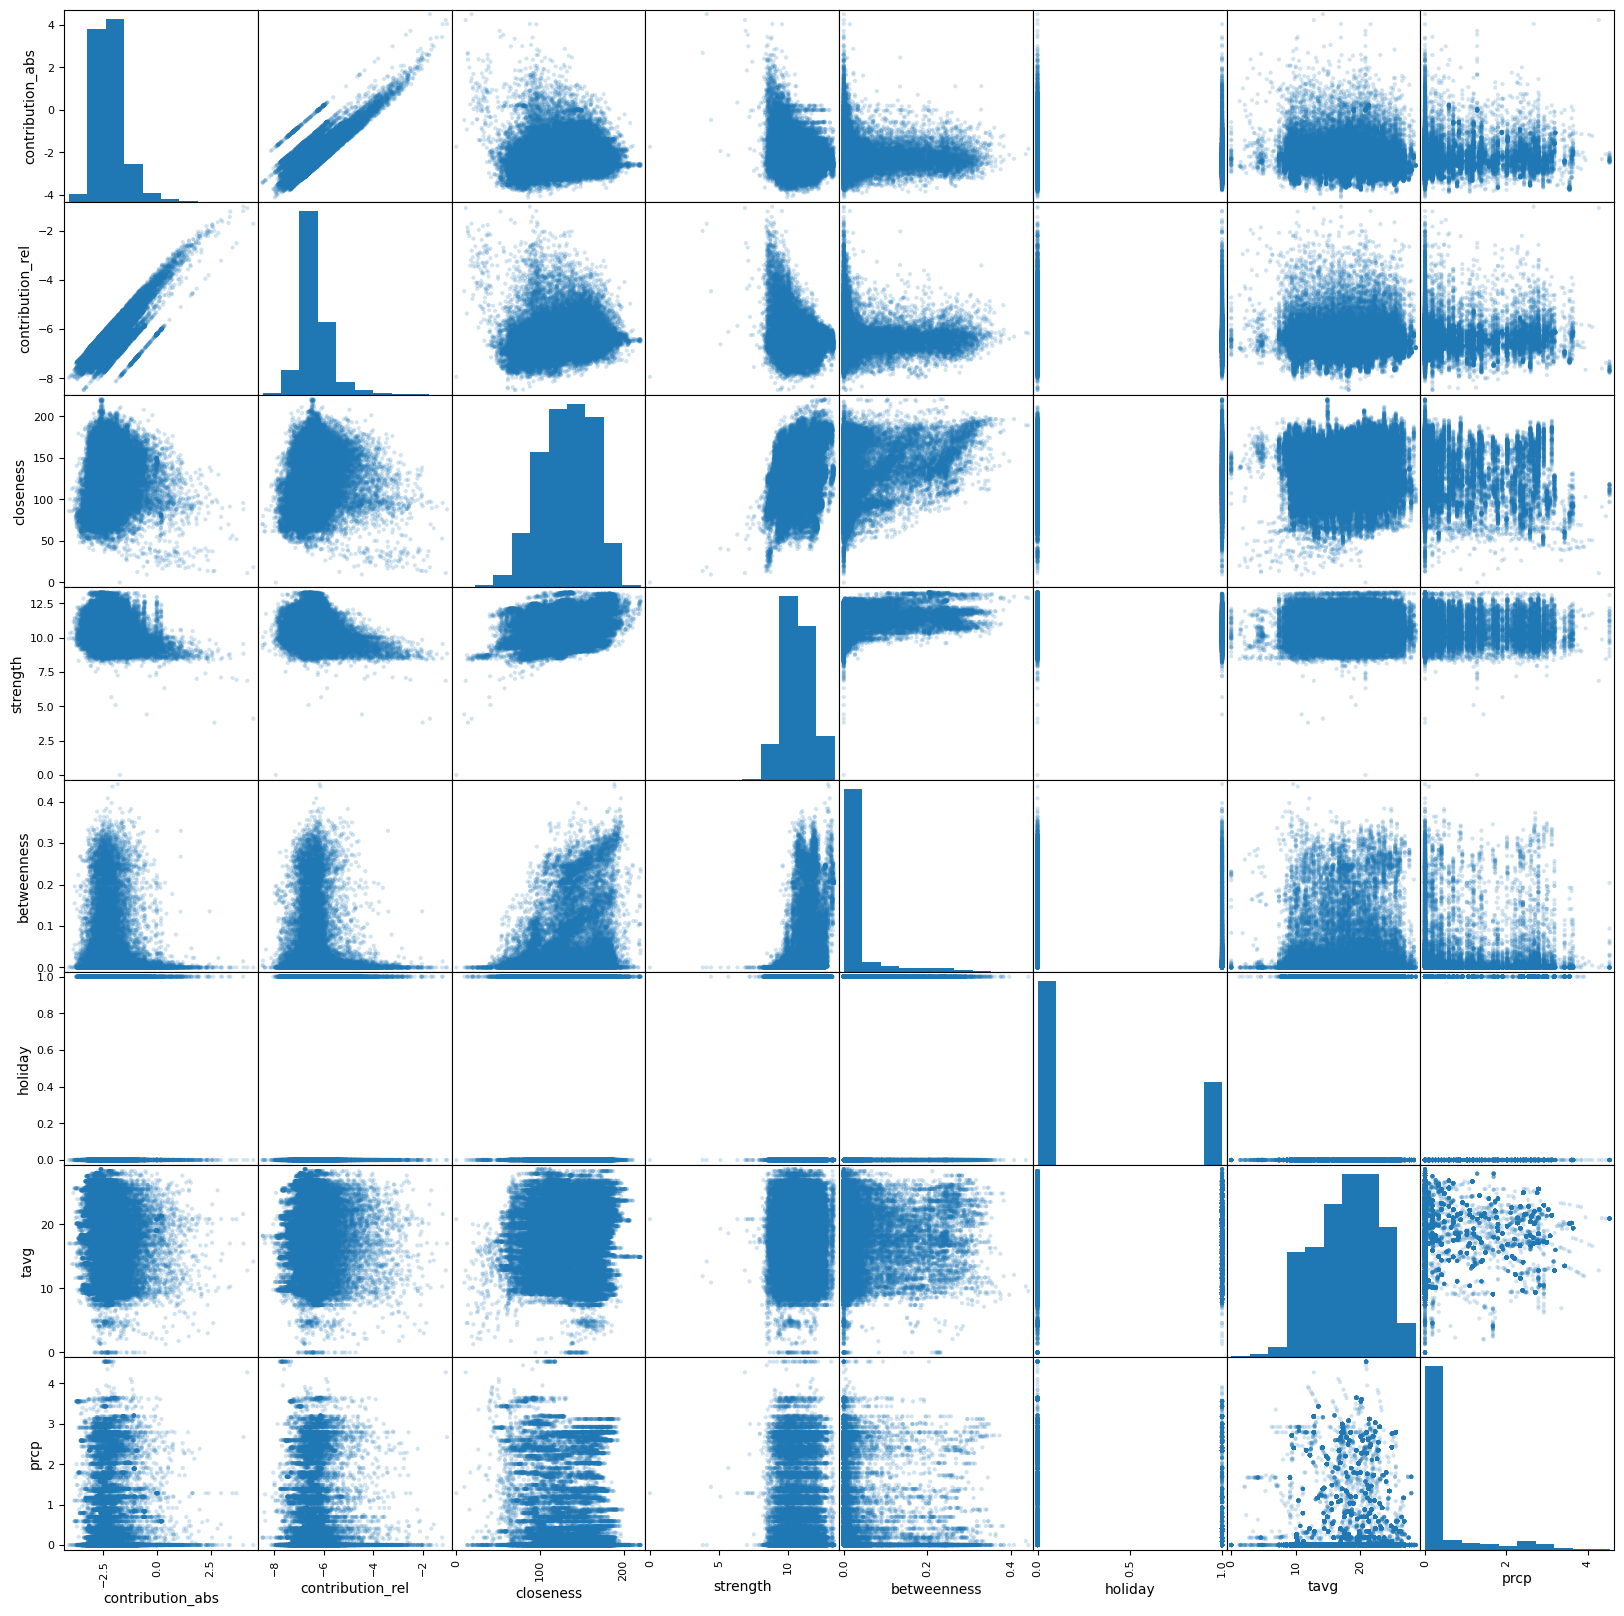

In [81]:
df_long_log = df_long.copy()
df_long_log = df_long_log.dropna()

df_long_log['contribution_abs'] = np.log(df_long_log['contribution_abs'])
df_long_log['contribution_rel'] = np.log(df_long_log['contribution_rel'])
df_long_log['strength'] = np.log1p(df_long_log['strength'])
df_long_log['betweenness'] = np.log1p(df_long_log['betweenness'])
df_long_log['prcp'] = np.log1p(df_long_log['prcp'])

pd.plotting.scatter_matrix(df_long_log[['contribution_abs', 'contribution_rel', 'closeness', 'strength', 'betweenness', 'holiday', 'tavg', 'prcp']], alpha=0.2, figsize=(20,20))

In [123]:
### DiD model ###
df_did = df_long_log[['day','districts','contribution_abs','closeness','strength','betweenness','holiday','tavg','prcp']].copy()

control_districts = set(gdf_SC.ID).difference(set(affected_by_DANA.ID))

# Crisis period dummy
crisis_start = pd.to_datetime("2024-10-29")
crisis_end   = pd.to_datetime("2024-11-01")

df_did['post'] = ((df_did['day'] >= crisis_start) & (df_did['day'] <= crisis_end)).astype(int)

# Treatment dummy
df_did['treated'] = (~df_did['districts'].isin(control_districts)).astype(int)

# DiD interaction
df_did['did'] = df_did['treated'] * df_did['post']

# Time trend, adding this cause pre-crisis trends are not parallel, there are structural differences in treated group
# the interaction term treated:time_trend will capture this differences
df_did['time_trend'] = (df_did['day'] - df_did['day'].min()).dt.days

In [117]:
import statsmodels.formula.api as smf

model_trend = smf.ols(
    """
    contribution_abs ~ did
    + treated:time_trend 
    + closeness + strength + betweenness
    + tavg + prcp 
    + C(districts) + C(day)
    """,
    data=df_did
).fit(cov_type='cluster', cov_kwds={'groups': df_did['districts']})

print(model_trend.summary())

                            OLS Regression Results                            
Dep. Variable:       contribution_abs   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                 6.186e+05
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:01:37   Log-Likelihood:                -32855.
No. Observations:               49259   AIC:                         6.679e+04
Df Residuals:                   48719   BIC:                         7.154e+04
Df Model:                         539                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [118]:
# Crisis window
crisis_start = pd.to_datetime("2024-10-29")
crisis_end   = pd.to_datetime("2024-11-01")

# Event time variable
df_did['event_time'] = (df_did['day'] - crisis_start).dt.days

# Keep only pre-crisis
pre = df_did[df_did['event_time'] < 0]

pre_model = smf.ols(
    "contribution_abs ~ treated * event_time + C(districts) + C(day)",
    data=pre
).fit()

print(pre_model.summary())

                            OLS Regression Results                            
Dep. Variable:       contribution_abs   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.460
Method:                 Least Squares   F-statistic:                     44.29
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:06:34   Log-Likelihood:                -15695.
No. Observations:               24032   AIC:                         3.234e+04
Df Residuals:                   23558   BIC:                         3.617e+04
Df Model:                         473                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [124]:
# Set panel index
df_did = df_did.set_index(['districts', 'day'])

model = PanelOLS.from_formula(
    """
    contribution_abs ~ did
    + treated:time_trend
    + closeness + strength + betweenness
    + tavg + prcp
    + EntityEffects + TimeEffects
    """,
    data=df_did,
    drop_absorbed=True
)

res = model.fit(cov_type='clustered', cluster_entity=True)
print(res.summary)

Variables have been fully absorbed and have removed from the regression:

did, treated:time_trend



                          PanelOLS Estimation Summary                           
Dep. Variable:       contribution_abs   R-squared:                        0.0045
Estimator:                   PanelOLS   R-squared (Between):              0.7555
No. Observations:               49259   R-squared (Within):               0.0271
Date:                Tue, Jun 23 2026   R-squared (Overall):              0.7120
Time:                        17:17:24   Log-likelihood                -3.286e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      44.502
Entities:                         417   P-value                           0.0000
Avg Obs:                       118.13   Distribution:                 F(5,48719)
Min Obs:                       111.00                                           
Max Obs:                       119.00   F-statistic (robust):             16.789
                            

## Analysis of closeness centrality

In [ ]:
centralities = pd.read_csv("/home/daltamirano/data/centralities_by_gender.csv")
centralities_glob = pd.read_csv("/home/daltamirano/data/centralities.csv")
centralities_glob['day'] = pd.to_datetime(centralities_glob['day'], format='%Y%m%d')
centralities_glob = centralities_glob.sort_values(by='day').reset_index(drop=True)

full_range = pd.date_range(start='2024-09-01', end='2024-12-31', freq='D')

daily_closeness_ratio, daily_closeness_women, daily_closeness_men = get_ratio_matrix_for_centralities(centralities, net_metric='closeness')
mean_closeness = daily_closeness_ratio.mean(axis=1)
std_closeness = daily_closeness_ratio.std(axis=1)

closeness_glob = pd.DataFrame.from_records(centralities_glob['closeness'].apply(ast.literal_eval))
daily_closeness_glob = pd.concat([centralities_glob[['day']].reset_index(drop=True), closeness_glob], axis=1)


daily_strength_ratio, daily_strength_women, daily_strength_men = get_ratio_matrix_for_centralities(centralities, net_metric='strength')
mean_strength = daily_strength_ratio.mean(axis=1)
std_strength = daily_strength_ratio.std(axis=1)

strength_glob = pd.DataFrame.from_records(centralities_glob['strength'].apply(ast.literal_eval))
daily_strength_glob = pd.concat([centralities_glob[['day']].reset_index(drop=True), strength_glob], axis=1)


daily_betweenness_ratio, daily_betweenness_women, daily_betweenness_men = get_ratio_matrix_for_centralities(centralities, net_metric='betweenness')
mean_betweenness = daily_betweenness_ratio.mean(axis=1)
std_betweenness = daily_betweenness_ratio.std(axis=1)

betweenness_glob = pd.DataFrame.from_records(centralities_glob['betweenness'].apply(ast.literal_eval))
daily_betweenness_glob = pd.concat([centralities_glob[['day']].reset_index(drop=True), betweenness_glob], axis=1)


lowest_quartile, highest_quartile, counts_quartile = find_top_bottom_quartile_districts(daily_closeness_glob, low_quartile=0.25, top_quartile=0.75, threshold_persistance = 0.75)

In [7]:
typical_days = ['2024-10-23', '2024-10-16', '2024-10-09', '2024-10-02']

women_typical = daily_closeness_women.loc[typical_days].mean().sort_index()
women_peak = daily_closeness_women.loc['2024-10-30'].sort_index()
men_typical = daily_closeness_men.loc[typical_days].mean().sort_index()
men_peak = daily_closeness_men.loc['2024-10-30'].sort_index()

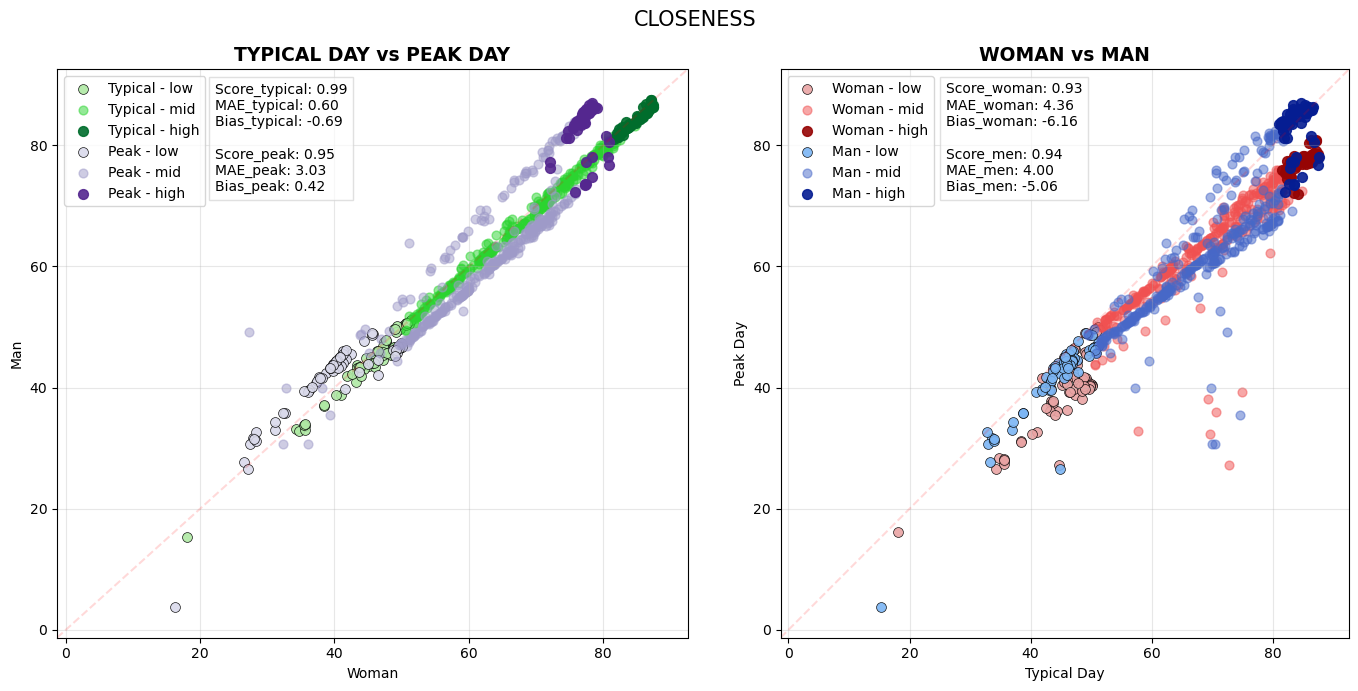

In [8]:
def score_out_diagonal(x, y):
    d = np.abs(y - x) / np.sqrt(2)
    mae_diag = d.mean()
    bias = np.mean(y - x)
    score = 1 - (mae_diag / (np.mean(np.abs(x)) + 1e-8))

    return score, mae_diag, bias

score_T, mae_diag_T, bias_T = score_out_diagonal(women_typical, men_typical)
score_P, mae_diag_P, bias_P = score_out_diagonal(women_peak, men_peak)
score_W, mae_diag_W, bias_W = score_out_diagonal(women_typical, women_peak)
score_M, mae_diag_M, bias_M = score_out_diagonal(men_typical, men_peak)

# sets to filter quickly and masks
lowest = set(lowest_quartile)
highest = set(highest_quartile)
idx = women_typical.index.sort_values()

low_mask = idx.isin(lowest)
high_mask = idx.isin(highest)
mid_mask = ~(low_mask | high_mask)

fig, axes = plt.subplots(1,2,figsize=(14,7))
fig.suptitle('CLOSENESS', fontsize=15)

# ── Left Panel: Men vs Women per day ─────────────────────────
ax = axes[0]

lims = [
    min(min(women_typical), min(men_typical), min(women_peak), min(men_peak)),
    max(max(women_typical), max(men_typical), max(women_peak), max(men_peak))
]
lims = [lims[0] - 5, lims[1] + 5]
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.plot(lims, lims, 'r--', alpha=0.15)
#ax.plot([min(women_peak), max(women_peak)], [min(men_peak), max(men_peak)], color='purple', linestyle='--')
#ax.plot([min(women_typical), max(women_typical)], [min(men_typical), max(men_typical)], color='darkgreen', linestyle='--')

# ===== TYPICAL
ax.scatter(women_typical[low_mask], men_typical[low_mask],
           color="#afe9a4", alpha=0.9, s=50, edgecolor='black', linewidth=0.5, label='Typical - low')

ax.scatter(women_typical[mid_mask], men_typical[mid_mask],
           color="#2bd430", alpha=0.5, s=40, label='Typical - mid')

ax.scatter(women_typical[high_mask], men_typical[high_mask],
           color='#006d2c', alpha=0.9, s=50, label='Typical - high')


# ===== PEAK
ax.scatter(women_peak[low_mask], men_peak[low_mask],
           color='#dadaeb', alpha=0.9, s=50, edgecolor='black', linewidth=0.5, label='Peak - low')

ax.scatter(women_peak[mid_mask], men_peak[mid_mask],
           color='#9e9ac8', alpha=0.5, s=40, label='Peak - mid')

ax.scatter(women_peak[high_mask], men_peak[high_mask],
           color='#54278f', alpha=0.9, s=50, label='Peak - high')

# labels
ax.set_xlabel('Woman')
ax.set_ylabel('Man')
ax.set_title('TYPICAL DAY vs PEAK DAY', fontweight='bold', fontsize=13.5)
ax.legend()#fontsize=8)
ax.grid(alpha=0.3)

ax.text(
    0.25, 0.977,
    f"Score_typical: {score_T:.2f}\nMAE_typical: {mae_diag_T:.2f}\nBias_typical: {bias_T:.2f}\n\nScore_peak: {score_P:.2f}\nMAE_peak: {mae_diag_P:.2f}\nBias_peak: {bias_P:.2f}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='lightgray')
)

# ── Right Panel: Men vs Women per day ─────────────────────────
ax2 = axes[1]

# ===== TYPICAL
ax2.scatter(women_typical[low_mask], women_peak[low_mask],
           color="#e9a4a4", alpha=0.9, s=50, edgecolor='black', linewidth=0.5, label='Woman - low')

ax2.scatter(women_typical[mid_mask], women_peak[mid_mask],
           color="#f05151", alpha=0.5, s=40, label='Woman - mid')

ax2.scatter(women_typical[high_mask], women_peak[high_mask],
           color="#960404", alpha=0.9, s=50, label='Woman - high')

# ===== PEAK
ax2.scatter(men_typical[low_mask], men_peak[low_mask],
           color="#7bb5f4", alpha=0.9, s=50, edgecolor='black', linewidth=0.5, label='Man - low')

ax2.scatter(men_typical[mid_mask], men_peak[mid_mask],
           color="#4768c8", alpha=0.5, s=40, label='Man - mid')

ax2.scatter(men_typical[high_mask], men_peak[high_mask],
           color="#051d92", alpha=0.9, s=50, label='Man - high')

#common_typical_peak = women_typical.index\
#                        .intersection(men_typical.index)\
#                        .intersection(women_peak.index)\
#                        .intersection(men_peak.index)
#
#for node in common_typical_peak:
#    ax2.plot(
#        [women_typical[node], men_typical[node]],
#        [women_peak[node], men_peak[node]],
#        color='gray', alpha=0.4, linewidth=0.7
#    )

ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.plot(lims, lims, 'r--', alpha=0.15)
#ax2.plot([min(men_typical), max(men_typical)], [min(men_peak), max(men_peak)], color='blue', linestyle='--')
#ax2.plot([min(women_typical), max(women_typical)], [min(women_peak), max(women_peak)], color='red', linestyle='--')
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlabel('Typical Day')
ax2.set_ylabel('Peak Day')
ax2.set_title('WOMAN vs MAN', fontweight='bold', fontsize=13.5)
ax2.legend()
ax2.grid(alpha=0.3)

ax2.text(
    1.41, 0.977,
    f"Score_woman: {score_W:.2f}\nMAE_woman: {mae_diag_W:.2f}\nBias_woman: {bias_W:.2f}\n\nScore_men: {score_M:.2f}\nMAE_men: {mae_diag_M:.2f}\nBias_men: {bias_M:.2f}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='lightgray')
)

fig.tight_layout()

**Normalization of the closeness**

Normal closeness centrality is given by the inverse of the sum of the weighted distances from node $i$ to node $j$, as follow,
\begin{equation}
    C_i = \frac{1}{\sum_{i \neq j} d_{ij}},
\end{equation}
where the distance $d_{ij}$ is the inverse of weights, $d_{ij} = \frac{1}{w_{ij}}$. Here we apply the normalization dividing the weights by the total weight, $W_{tot}$, which is a constant. Thus, the normalized closeness for weighted graphs is given by,
\begin{equation}
    C_i^N = \frac{1}{W_{tot}} C_i.
\end{equation}

In [ ]:
def trips_counting(df):
    outgoing = df.groupby("origin")["flow"].sum()
    outgoing = outgoing.sort_values(ascending=False)
    incoming = df.groupby("destination")["flow"].sum()
    incoming = incoming.sort_values(ascending=False)
    total = outgoing.add(incoming, fill_value=0)
    total = total.sort_values(ascending=False)

    return outgoing, incoming, total


typical_days_spark = [20241023, 20241016, 20241009, 20241002]
peak_day_spark = 20241030

#df_typical = (df_study_case.filter(F.col('fecha').isin(set(typical_days_spark))).groupBy('origen', 'destino', 'sexo').agg(F.sum('total_trips').alias('total_trips')).toPandas())
#df_typical['total_trips'] = df_typical['total_trips']/len(typical_days_spark)
#fdf_typical = df_typical.rename(columns={'origen': 'origin', 'destino': 'destination', 'total_trips': 'flow'})
#fdf_typical.to_csv("/data/big/davidaltamirano/SC_Valencia_comunidad/gender_flows_typical.csv", index=False)

#df_peak = (df_study_case.filter(F.col('fecha') == peak_day_spark).groupBy('origen', 'destino', 'sexo').agg(F.sum('total_trips').alias('total_trips')).toPandas())
#fdf_peak = df_peak.rename(columns={'origen': 'origin', 'destino': 'destination', 'total_trips': 'flow'})
#fdf_peak.to_csv("/data/big/davidaltamirano/SC_Valencia_comunidad/gender_flows_peak.csv", index=False)

In [32]:
fdf_typical = pd.read_csv("/data/big/davidaltamirano/SC_Valencia_comunidad/gender_flows_typical.csv")
fdf_peak = pd.read_csv("/data/big/davidaltamirano/SC_Valencia_comunidad/gender_flows_peak.csv")

outgoing_T_M, incoming_T_M, total_T_M = trips_counting(fdf_typical[fdf_typical.sexo == "hombre"])
outgoing_T_W, incoming_T_W, total_T_W = trips_counting(fdf_typical[fdf_typical.sexo == "mujer"])
outgoing_P_M, incoming_P_M, total_P_M = trips_counting(fdf_peak[fdf_peak.sexo == "hombre"])
outgoing_P_W, incoming_P_W, total_P_W = trips_counting(fdf_peak[fdf_peak.sexo == "mujer"])

In [16]:
women_typical = women_typical / total_T_W.sum()
women_peak = women_peak / total_P_W.sum()
men_typical = men_typical / total_T_M.sum()
men_peak = men_peak / total_P_M.sum()

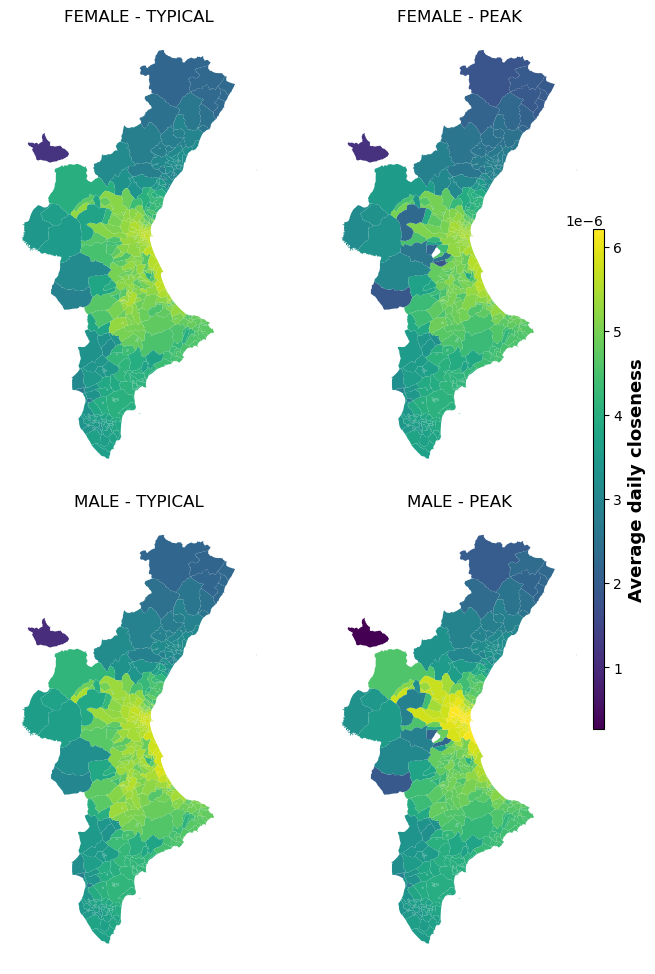

In [82]:
women_typical.index = women_typical.index.map(dict_SC_inv)
women_peak.index = women_peak.index.map(dict_SC_inv)
men_typical.index = men_typical.index.map(dict_SC_inv)
men_peak.index = men_peak.index.map(dict_SC_inv)

gdf_SC_TP = gdf_SC.copy()
gdf_SC_TP['close_W_typ'] = gdf_SC_TP['ID'].map(women_typical)
gdf_SC_TP['close_M_typ'] = gdf_SC_TP['ID'].map(men_typical)
gdf_SC_TP['close_W_peak'] = gdf_SC_TP['ID'].map(women_peak)
gdf_SC_TP['close_M_peak'] = gdf_SC_TP['ID'].map(men_peak)

fig, ax = plt.subplots(2, 2, figsize=(7,10))
#plt.suptitle('CLOSENESS\n', fontweight='bold', fontsize=15)

vmax0 = max(gdf_SC_TP['close_W_typ'].max(), gdf_SC_TP['close_M_typ'].max(), gdf_SC_TP['close_W_peak'].max(), gdf_SC_TP['close_M_peak'].max())
vmin0 = min(gdf_SC_TP['close_W_typ'].min(), gdf_SC_TP['close_M_typ'].min(), gdf_SC_TP['close_W_peak'].min(), gdf_SC_TP['close_M_peak'].min())

gdf_SC_TP.plot(
    ax=ax[0,0],
    column='close_W_typ',
    cmap='viridis',
    vmin=vmin0,
    vmax=vmax0,
)
ax[0,0].axis("off")
ax[0,0].set_title('FEMALE - TYPICAL')

gdf_SC_TP.plot(
    ax=ax[0,1],
    column='close_W_peak',
    cmap='viridis',
    vmin=vmin0,
    vmax=vmax0,
)
ax[0,1].axis("off")
ax[0,1].set_title('FEMALE - PEAK')

gdf_SC_TP.plot(
    ax=ax[1,0],
    column='close_M_typ',
    cmap='viridis',
    vmin=vmin0,
    vmax=vmax0,
)
ax[1,0].axis("off")
ax[1,0].set_title('MALE - TYPICAL')

gdf_SC_TP.plot(
    ax=ax[1,1],
    column='close_M_peak',
    cmap='viridis',
    vmin=vmin0,
    vmax=vmax0,
)
ax[1,1].axis("off")
ax[1,1].set_title('MALE - PEAK')

fig.tight_layout()

norm = mpl.colors.Normalize(vmin=vmin0, vmax=vmax0)
sm = mpl.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])

cbar = fig.colorbar(sm, cax=cax, orientation="vertical")
cbar.set_label("Average daily closeness", fontsize=13, fontweight='bold')

plt.savefig('norm_avg_closeness_TvsP.png', dpi=300, bbox_inches='tight')

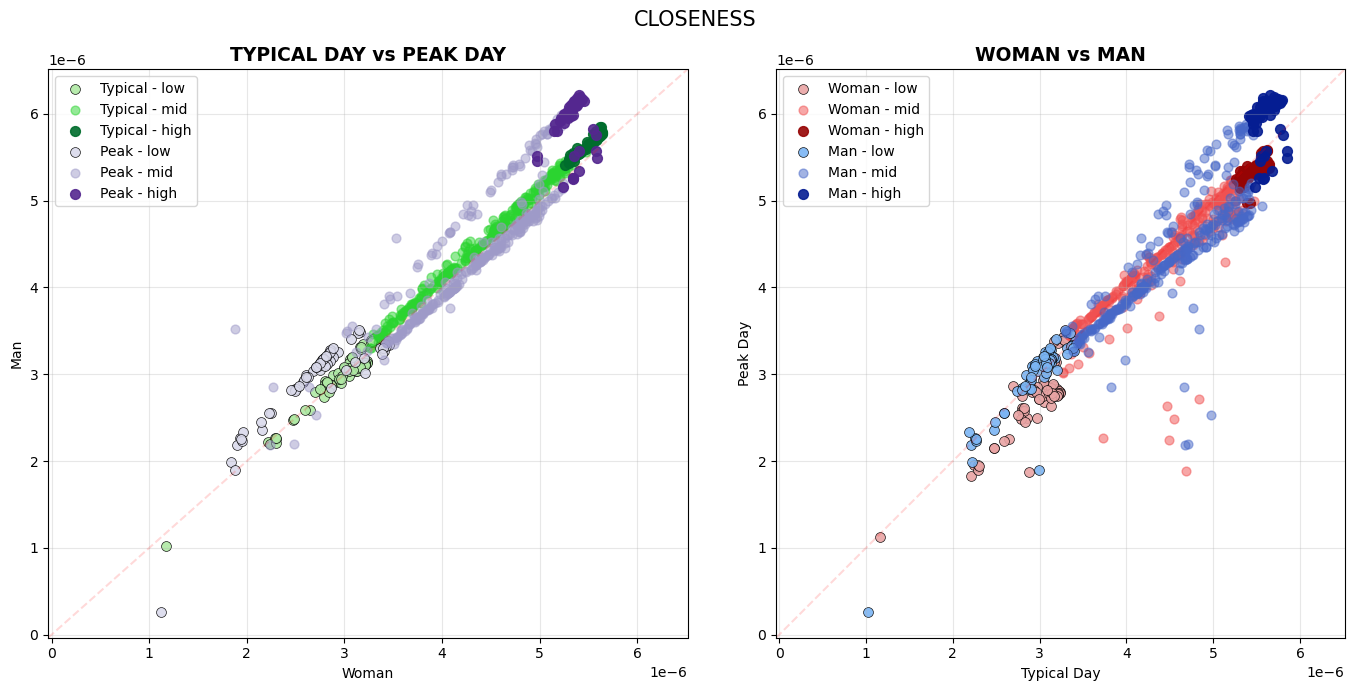

In [83]:
women_typical.index = women_typical.index.map(dict_SC)
women_peak.index = women_peak.index.map(dict_SC)
men_typical.index = men_typical.index.map(dict_SC)
men_peak.index = men_peak.index.map(dict_SC)

# sets to filter quickly and masks
lowest = set(lowest_quartile)
highest = set(highest_quartile)
idx = women_typical.index.sort_values()

low_mask = idx.isin(lowest)
high_mask = idx.isin(highest)
mid_mask = ~(low_mask | high_mask)

fig, axes = plt.subplots(1,2,figsize=(14,7))
fig.suptitle('CLOSENESS', fontsize=15)

# ── Left Panel: Men vs Women per day ─────────────────────────
ax = axes[0]

lims = [
    min(min(women_typical), min(men_typical), min(women_peak), min(men_peak)),
    max(max(women_typical), max(men_typical), max(women_peak), max(men_peak))
]
lims = [lims[0] - 3e-07, lims[1] + 3e-07]
#lims = [lims[0] - 5, lims[1] + 5]
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.plot(lims, lims, 'r--', alpha=0.15)
#ax.plot([min(women_peak), max(women_peak)], [min(men_peak), max(men_peak)], color='purple', linestyle='--')
#ax.plot([min(women_typical), max(women_typical)], [min(men_typical), max(men_typical)], color='darkgreen', linestyle='--')

# ===== TYPICAL
ax.scatter(women_typical[low_mask], men_typical[low_mask],
           color="#afe9a4", alpha=0.9, s=50, edgecolor='black', linewidth=0.5, label='Typical - low')

ax.scatter(women_typical[mid_mask], men_typical[mid_mask],
           color="#2bd430", alpha=0.5, s=40, label='Typical - mid')

ax.scatter(women_typical[high_mask], men_typical[high_mask],
           color='#006d2c', alpha=0.9, s=50, label='Typical - high')


# ===== PEAK
ax.scatter(women_peak[low_mask], men_peak[low_mask],
           color='#dadaeb', alpha=0.9, s=50, edgecolor='black', linewidth=0.5, label='Peak - low')

ax.scatter(women_peak[mid_mask], men_peak[mid_mask],
           color='#9e9ac8', alpha=0.5, s=40, label='Peak - mid')

ax.scatter(women_peak[high_mask], men_peak[high_mask],
           color='#54278f', alpha=0.9, s=50, label='Peak - high')

# labels
ax.set_xlabel('Woman')
ax.set_ylabel('Man')
ax.set_title('TYPICAL DAY vs PEAK DAY', fontweight='bold', fontsize=13.5)
ax.legend()#fontsize=8)
ax.grid(alpha=0.3)


# ── Right Panel: Men vs Women per day ─────────────────────────
ax2 = axes[1]

# ===== TYPICAL
ax2.scatter(women_typical[low_mask], women_peak[low_mask],
           color="#e9a4a4", alpha=0.9, s=50, edgecolor='black', linewidth=0.5, label='Woman - low')

ax2.scatter(women_typical[mid_mask], women_peak[mid_mask],
           color="#f05151", alpha=0.5, s=40, label='Woman - mid')

ax2.scatter(women_typical[high_mask], women_peak[high_mask],
           color="#960404", alpha=0.9, s=50, label='Woman - high')

# ===== PEAK
ax2.scatter(men_typical[low_mask], men_peak[low_mask],
           color="#7bb5f4", alpha=0.9, s=50, edgecolor='black', linewidth=0.5, label='Man - low')

ax2.scatter(men_typical[mid_mask], men_peak[mid_mask],
           color="#4768c8", alpha=0.5, s=40, label='Man - mid')

ax2.scatter(men_typical[high_mask], men_peak[high_mask],
           color="#051d92", alpha=0.9, s=50, label='Man - high')


ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.plot(lims, lims, 'r--', alpha=0.15)
#ax2.plot([min(men_typical), max(men_typical)], [min(men_peak), max(men_peak)], color='blue', linestyle='--')
#ax2.plot([min(women_typical), max(women_typical)], [min(women_peak), max(women_peak)], color='red', linestyle='--')
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlabel('Typical Day')
ax2.set_ylabel('Peak Day')
ax2.set_title('WOMAN vs MAN', fontweight='bold', fontsize=13.5)
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()

plt.savefig('norm_closeness_scatters.png', dpi=300, bbox_inches='tight')

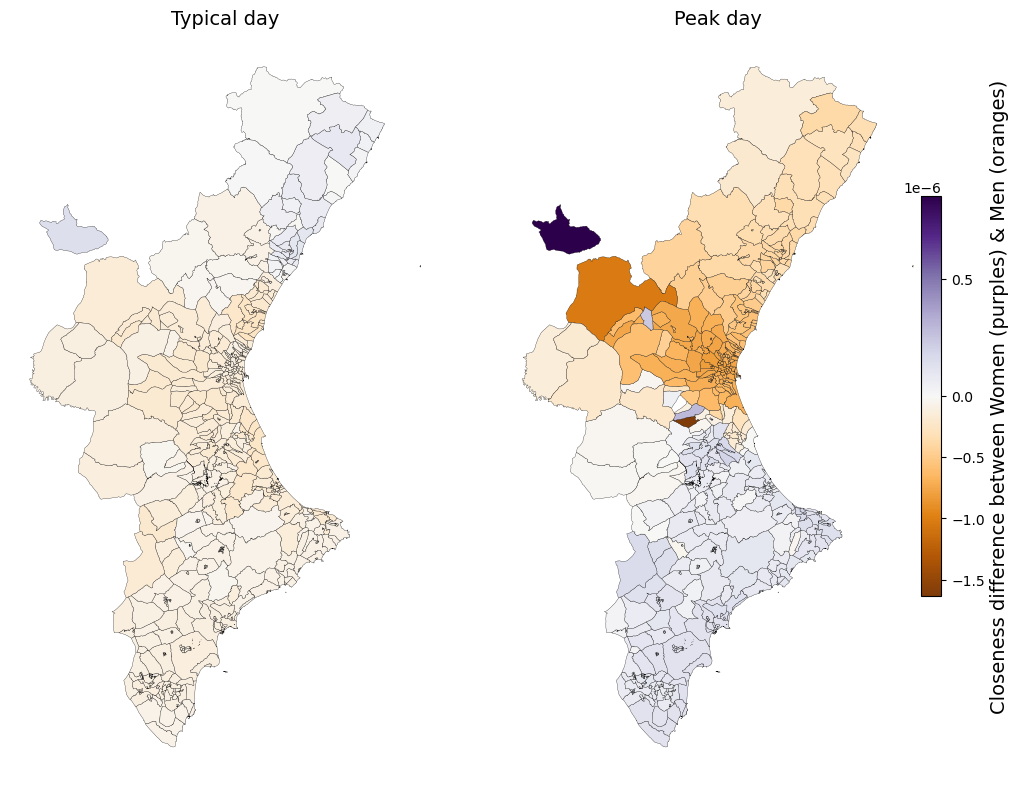

In [84]:
typ_diff = women_typical - men_typical
typ_diff.index = typ_diff.index.map(dict_SC_inv)
peak_diff = women_peak - men_peak
peak_diff.index = peak_diff.index.map(dict_SC_inv)
men_diff = men_typical - men_peak
men_diff.index = men_diff.index.map(dict_SC_inv)
women_diff = women_typical - women_peak
women_diff.index = women_diff.index.map(dict_SC_inv)

gdf_diff = gdf_SC.copy()
gdf_diff['diff_typ'] = gdf_diff['ID'].map(typ_diff)
gdf_diff['diff_peak'] = gdf_diff['ID'].map(peak_diff)
gdf_diff['diff_men'] = gdf_diff['ID'].map(men_diff)
gdf_diff['diff_women'] = gdf_diff['ID'].map(women_diff)

vmax = max(gdf_diff['diff_typ'].max(), gdf_diff['diff_peak'].max())
vmin = min(gdf_diff['diff_typ'].min(), gdf_diff['diff_peak'].min())
#vmax = max(np.abs(vmax), np.abs(vmin))
#vmin = -vmax
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(1, 2, figsize=(10, 8))

gdf_diff.plot(
    ax=ax[0],
    column='diff_typ',
    cmap='PuOr',
    norm=norm,
    vmin=vmin,
    vmax=vmax,
    legend=False,
    linewidth=0.2,
    edgecolor="black"
)
ax[0].set_title('Typical day', fontsize=14)
ax[0].axis('off')

gdf_diff.plot(
    ax=ax[1],
    column='diff_peak',
    cmap='PuOr',
    norm=norm,
    vmin=vmin,
    vmax=vmax,
    legend=False,
    linewidth=0.2,
    edgecolor="black"
)
ax[1].set_title('Peak day', fontsize=14)
ax[1].axis('off')

sm = mpl.cm.ScalarMappable(cmap='PuOr', norm=norm)
sm.set_array([])
cax = fig.add_axes([0.95, 0.25, 0.02, 0.5])
cbar = fig.colorbar(sm, cax=cax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Closeness difference between Women (purples) & Men (oranges)', fontsize=14)

plt.tight_layout()

plt.savefig('norm_closeness_scatter_MAP.png', dpi=300, bbox_inches='tight')

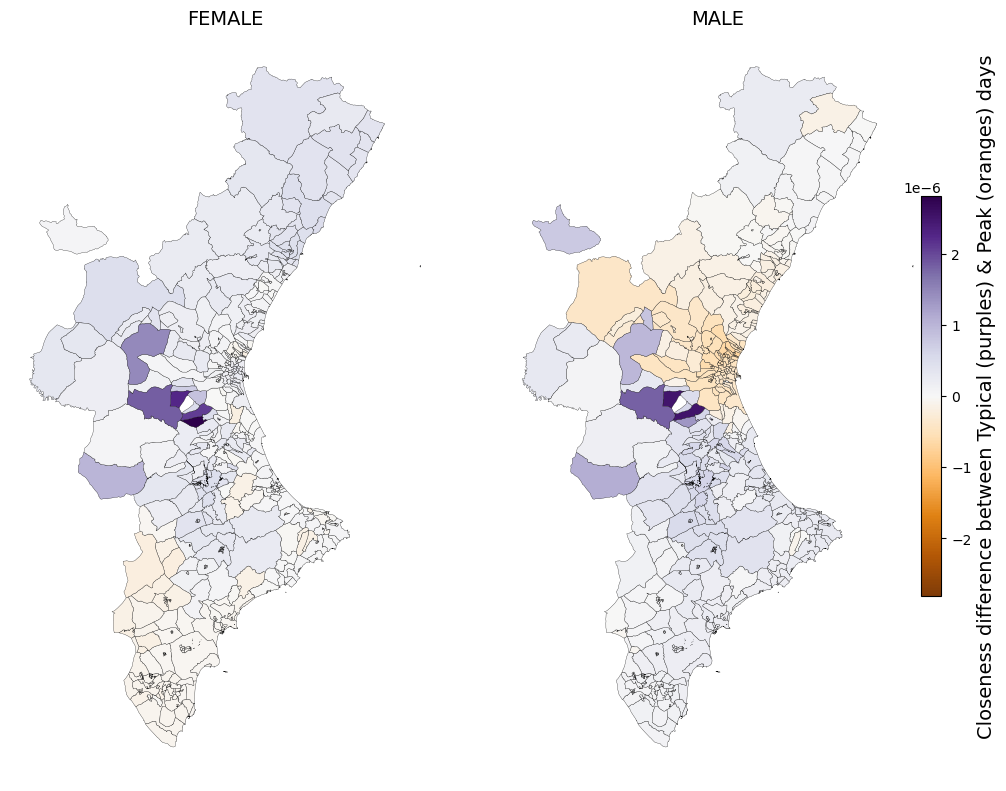

In [20]:
vmax = max(gdf_diff['diff_men'].max(), gdf_diff['diff_women'].max())    # 45.44485651059554
#vmin = min(gdf_diff['diff_men'].min(), gdf_diff['diff_women'].min())    # -5.339241341734024
vmin = -vmax
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(1, 2, figsize=(10, 8))

gdf_diff.plot(
    ax=ax[0],
    column='diff_women',
    cmap='PuOr',
    norm=norm,
    vmin=vmin,
    vmax=vmax,
    legend=False,
    linewidth=0.2,
    edgecolor="black"
)
ax[0].set_title('FEMALE', fontsize=14)
ax[0].axis('off')

gdf_diff.plot(
    ax=ax[1],
    column='diff_men',
    cmap='PuOr',
    norm=norm,
    vmin=vmin,
    vmax=vmax,
    legend=False,
    linewidth=0.2,
    edgecolor="black"
)
ax[1].set_title('MALE', fontsize=14)
ax[1].axis('off')

sm = mpl.cm.ScalarMappable(cmap='PuOr', norm=norm)
sm.set_array([])
cax = fig.add_axes([0.95, 0.25, 0.02, 0.5])
cbar = fig.colorbar(sm, cax=cax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Closeness difference between Typical (purples) & Peak (oranges) days', fontsize=14)
# in purple the most affected areas in the peak day

plt.tight_layout()

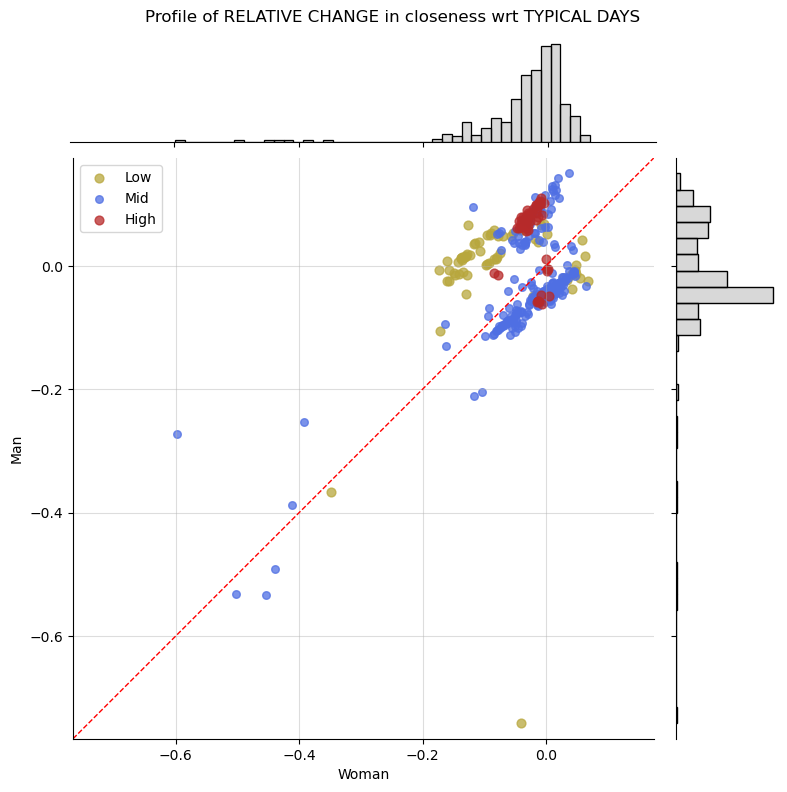

In [21]:
x = (women_peak - women_typical) / women_typical
y = (men_peak - men_typical) / men_typical

#x = x[x.values > x.quantile(0.025)]
#y = y[y.values > y.quantile(0.025)]

idx = x.index.sort_values()
low_mask = idx.isin(lowest)
high_mask = idx.isin(highest)
mid_mask = ~(low_mask | high_mask)

# create the figure
g = sns.JointGrid(x=x, y=y, height=8)

# ===== SCATTER  =====

# LOW
g.ax_joint.scatter(x[low_mask], y[low_mask],
                   color="#B8A73D", alpha=0.75, s=40, label='Low')

# MID
g.ax_joint.scatter(x[mid_mask], y[mid_mask],
                   color="#4f6fe3", alpha=0.75, s=30, label='Mid')

# HIGH
g.ax_joint.scatter(x[high_mask], y[high_mask],
                   color="#b72a2a", alpha=0.75, s=40, label='High')

# ===== MARGINS =====
g.plot_marginals(sns.histplot, kde=False, color='grey', alpha=0.3)

g.set_axis_labels("Woman", "Man")
g.fig.suptitle('Profile of RELATIVE CHANGE in closeness wrt TYPICAL DAYS')

# ===== DIAGONAL =====
lims = [
    min(min(x), min(y)),
    max(max(x), max(y))
]
lims = [lims[0] - 0.025, lims[1] + 0.025]

g.ax_joint.plot(lims, lims, 'r--', linewidth=1)

g.ax_joint.set_xlim(lims)
g.ax_joint.set_ylim(lims)
g.ax_joint.set_aspect('equal', adjustable='box')

# grid
g.ax_joint.grid(alpha=0.42)

# leyenda
g.ax_joint.legend()

plt.tight_layout()

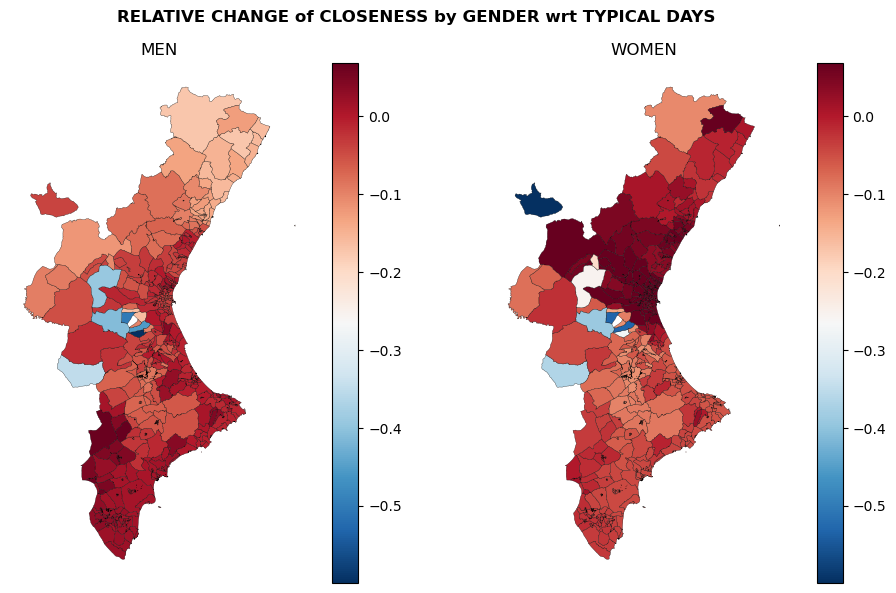

In [22]:
x.index = x.index.map(dict_SC_inv)
y.index = y.index.map(dict_SC_inv)

gdf_SC_rel_change_TP = gdf_SC.copy()
gdf_SC_rel_change_TP['close_rel_M'] = gdf_SC_rel_change_TP['ID'].map(x)
gdf_SC_rel_change_TP['close_rel_W'] = gdf_SC_rel_change_TP['ID'].map(y)

fig, ax = plt.subplots(1, 2, figsize=(10,6))
plt.suptitle('RELATIVE CHANGE of CLOSENESS by GENDER wrt TYPICAL DAYS', fontweight='bold')#, fontsize=15)

vmax = gdf_SC_rel_change_TP['close_rel_M'].max()
vmin = gdf_SC_rel_change_TP['close_rel_M'].min()

#gdf_SC_rel_change_TP[gdf_SC_rel_change_TP.close_peak != gdf_SC_rel_change_TP.close_peak.max()].plot(
gdf_SC_rel_change_TP.plot(
    ax=ax[0],
    column='close_rel_M',
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    legend=True,
    linewidth=0.2,
    edgecolor="black"
)
ax[0].axis("off")
ax[0].set_title('MEN')

gdf_SC_rel_change_TP.plot(
    ax=ax[1],
    column='close_rel_W',
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    legend=True,
    linewidth=0.2,
    edgecolor="black"
)
ax[1].axis("off")
ax[1].set_title('WOMEN')

fig.tight_layout()

### Radiation Model


\begin{equation*}
    T_{ij} = T_i\ \frac{1}{1-\frac{m_i}{M}}\ \frac{m_i\ m_j}{(m_i + s_{ij})(m_i+m_j+s_{ij})}
\end{equation*}

where $T_i$ is the total outflow of origin, \
$m_i$ is the 'mass' or 'relevance' (population) of origen, \
$m_j$ is the 'mass' or 'relevance' (population) of destination, \
$s_{ij}$ is the total population in a close circle centered in $i$ with radius $j$.

In [ ]:
gdf_SC_poblacion = gdf_SC.to_crs(epsg=4326)
gdf_SC_poblacion['lon'] = gdf_SC_poblacion.centroid.x
gdf_SC_poblacion['lat'] = gdf_SC_poblacion.centroid.y

gdf_SC_poblacion = gdf_SC_poblacion.merge(poblacion[poblacion['distrito'].isin(SC_districts)], left_on="ID", right_on="distrito")
gdf_SC_poblacion = gdf_SC_poblacion.drop(columns=["distrito", "municipio", "provincia"])
tessellation = gdf_SC_poblacion.rename(columns={'ID': 'tile_id', 'poblacion': 'population'})

In [ ]:
typical_days_spark = [20241023, 20241016, 20241009, 20241002]
peak_day_spark = 20241030

df_typical = (df_study_case.filter(F.col('fecha').isin(set(typical_days_spark))).groupBy('origen', 'destino', 'sexo').agg(F.sum('total_trips').alias('total_trips')).toPandas())
df_typical['total_trips'] = df_typical['total_trips']/len(typical_days_spark)
fdf_typical = df_typical.rename(columns={'origen': 'origin', 'destino': 'destination', 'total_trips': 'flow'})

df_peak = (df_study_case.filter(F.col('fecha') == peak_day_spark).groupBy('origen', 'destino', 'sexo').agg(F.sum('total_trips').alias('total_trips')).toPandas())
fdf_peak = df_peak.rename(columns={'origen': 'origin', 'destino': 'destination', 'total_trips': 'flow'})

tot_outflows_T_M = fdf_typical[(fdf_typical['origin'] != fdf_typical['destination']) & (fdf_typical.sexo == 'hombre')].groupby(by='origin', axis=0)[['flow']].sum().fillna(0)
tessellation_T_M = tessellation.merge(tot_outflows_T_M, left_on='tile_id', right_on='origin').rename(columns={'flow': 'tot_outflow'})
tot_outflows_T_F = fdf_typical[(fdf_typical['origin'] != fdf_typical['destination']) & (fdf_typical.sexo == 'mujer')].groupby(by='origin', axis=0)[['flow']].sum().fillna(0)
tessellation_T_F = tessellation.merge(tot_outflows_T_F, left_on='tile_id', right_on='origin').rename(columns={'flow': 'tot_outflow'})

tot_outflows_P_M = fdf_peak[(fdf_peak['origin'] != fdf_peak['destination']) & (fdf_peak.sexo == 'hombre')].groupby(by='origin', axis=0)[['flow']].sum().fillna(0)
tessellation_P_M = tessellation.merge(tot_outflows_P_M, left_on='tile_id', right_on='origin', how='left').rename(columns={'flow': 'tot_outflow'})
tessellation_P_M = tessellation_P_M[tessellation_P_M.tile_id != '46176']
tot_outflows_P_F = fdf_peak[(fdf_peak['origin'] != fdf_peak['destination']) & (fdf_peak.sexo == 'mujer')].groupby(by='origin', axis=0)[['flow']].sum().fillna(0)
tessellation_P_F = tessellation.merge(tot_outflows_P_F, left_on='tile_id', right_on='origin', how='left').rename(columns={'flow': 'tot_outflow'})
tessellation_P_F = tessellation_P_F[tessellation_P_F.tile_id != '46176']

In [ ]:
syn_model_T_M = radiation_model(tessellation_T_M)
syn_model_T_F = radiation_model(tessellation_T_F)
syn_model_P_M = radiation_model(tessellation_P_M)
syn_model_P_F = radiation_model(tessellation_P_F)

In [ ]:
OD_original_T_F = fdf_typical[fdf_typical.sexo == 'mujer'].pivot(index='origin', columns='destination', values='flow').fillna(0)
OD_syntheti_T_F = syn_model_T_F.pivot(index='origin', columns='destination', values='flow').fillna(0)

common_part_of_commuters(OD_original_T_F.values.flatten(), OD_syntheti_T_F.values.flatten())    # np.float64(0.47138201312766376)

In [ ]:
OD_original_P_F = fdf_peak[fdf_peak.sexo == 'mujer'].pivot(index='origin', columns='destination', values='flow').fillna(0)
OD_syntheti_P_F = syn_model_P_F.pivot(index='origin', columns='destination', values='flow').fillna(0)

common_part_of_commuters(OD_original_P_F.values.flatten(), OD_syntheti_P_F.values.flatten())    # np.float64(0.4777526138835487)

**How well does the closeness obtained from the radiation model reproduce the observed closeness?**

$\Delta C_{obs}^G = \alpha + \beta\ \Delta C_{syn}^G + \epsilon$

where $\Delta$ refers to the closeess difference between the typical and peak day, and $G$ is the gender.

In [ ]:
G_obs_T = nx.from_pandas_edgelist(fdf_typical[fdf_typical.sexo == 'mujer'], source='origin', target='destination', edge_attr='flow', create_using=nx.DiGraph())
G_syn_T = nx.from_pandas_edgelist(syn_model_T_F.fillna(0), source='origin', target='destination', edge_attr='flow', create_using=nx.DiGraph())
G_obs_P = nx.from_pandas_edgelist(fdf_peak[fdf_peak.sexo == 'mujer'], source='origin', target='destination', edge_attr='flow', create_using=nx.DiGraph())
G_syn_P = nx.from_pandas_edgelist(syn_model_P_F.fillna(0), source='origin', target='destination', edge_attr='flow', create_using=nx.DiGraph())

gdf_obs_T_F = map_closeness(G_obs_T, gdf_SC)
gdf_syn_T_F = map_closeness(G_syn_T, gdf_SC)
gdf_obs_P_F = map_closeness(G_obs_P, gdf_SC)
gdf_syn_P_F = map_closeness(G_syn_P, gdf_SC)

G_obs_T = nx.from_pandas_edgelist(fdf_typical[fdf_typical.sexo == 'hombre'], source='origin', target='destination', edge_attr='flow', create_using=nx.DiGraph())
G_syn_T = nx.from_pandas_edgelist(syn_model_T_M.fillna(0), source='origin', target='destination', edge_attr='flow', create_using=nx.DiGraph())
G_obs_P = nx.from_pandas_edgelist(fdf_peak[fdf_peak.sexo == 'hombre'], source='origin', target='destination', edge_attr='flow', create_using=nx.DiGraph())
G_syn_P = nx.from_pandas_edgelist(syn_model_P_M.fillna(0), source='origin', target='destination', edge_attr='flow', create_using=nx.DiGraph())

gdf_obs_T_M = map_closeness(G_obs_T, gdf_SC)
gdf_syn_T_M = map_closeness(G_syn_T, gdf_SC)
gdf_obs_P_M = map_closeness(G_obs_P, gdf_SC)
gdf_syn_P_M = map_closeness(G_syn_P, gdf_SC)

In [ ]:
gdf_obs_TP_F = gdf_obs_T_F.merge(gdf_obs_P_F, on=['ID', 'geometry', 'node']).fillna(0)
gdf_obs_TP_F['delta'] = (gdf_obs_TP_F['closeness_y'] - gdf_obs_TP_F['closeness_x']) # / gdf_obs_TP_F['closeness_x']      # Peak - Typical
gdf_syn_TP_F = gdf_syn_T_F.merge(gdf_syn_P_F, on=['ID', 'geometry', 'node']).fillna(0)
gdf_syn_TP_F['delta'] = (gdf_syn_TP_F['closeness_y'] - gdf_syn_TP_F['closeness_x']) # / gdf_syn_TP_F['closeness_x']      # Peak - Typical

gdf_obs_TP_M = gdf_obs_T_M.merge(gdf_obs_P_M, on=['ID', 'geometry', 'node']).fillna(0)
gdf_obs_TP_M['delta'] = (gdf_obs_TP_M['closeness_y'] - gdf_obs_TP_M['closeness_x']) # / gdf_obs_TP_M['closeness_x']      # Peak - Typical
gdf_syn_TP_M = gdf_syn_T_M.merge(gdf_syn_P_M, on=['ID', 'geometry', 'node']).fillna(0)
gdf_syn_TP_M['delta'] = (gdf_syn_TP_M['closeness_y'] - gdf_syn_TP_M['closeness_x']) # / gdf_syn_TP_M['closeness_x']      # Peak - Typical

In [ ]:
delta_obs_F = gdf_obs_TP_F["delta"].dropna().values
delta_syn_F = gdf_syn_TP_F["delta"].dropna().values

delta_obs_M = gdf_obs_TP_M["delta"].dropna().values
delta_syn_M = gdf_syn_TP_M["delta"].dropna().values

spearman_M = stats.spearmanr(delta_obs_M, delta_syn_M)
spearman_F = stats.spearmanr(delta_obs_F, delta_syn_F)

results_regression = pd.DataFrame([{"gender": "Male", **stats.linregress(delta_syn_M, delta_obs_M)._asdict(), "spearman_rvalue": spearman_M[0], "spearman_pvalue": spearman_M[1]},
                                   {"gender": "Female", **stats.linregress(delta_syn_F, delta_obs_F)._asdict(), "spearman_rvalue": spearman_F[0], "spearman_pvalue": spearman_F[1]}]) \
                                .set_index('gender')

results_regression

### Closeness hotspots with lorenz

In [11]:
women_typical.index = women_typical.index.map(dict_SC_inv)
women_peak.index = women_peak.index.map(dict_SC_inv)
men_typical.index = men_typical.index.map(dict_SC_inv)
men_peak.index = men_peak.index.map(dict_SC_inv)

women_typical.name = "closeness"
women_peak.name = "closeness"
men_typical.name = "closeness"
men_peak.name = "closeness"

gdf_T_M = gdf_SC.merge(men_typical, left_on="ID", right_index=True, how='left')
gdf_T_F = gdf_SC.merge(women_typical, left_on="ID", right_index=True, how='left')
gdf_P_M = gdf_SC.merge(men_peak, left_on="ID", right_index=True, how='left')
gdf_P_F = gdf_SC.merge(women_peak, left_on="ID", right_index=True, how='left')

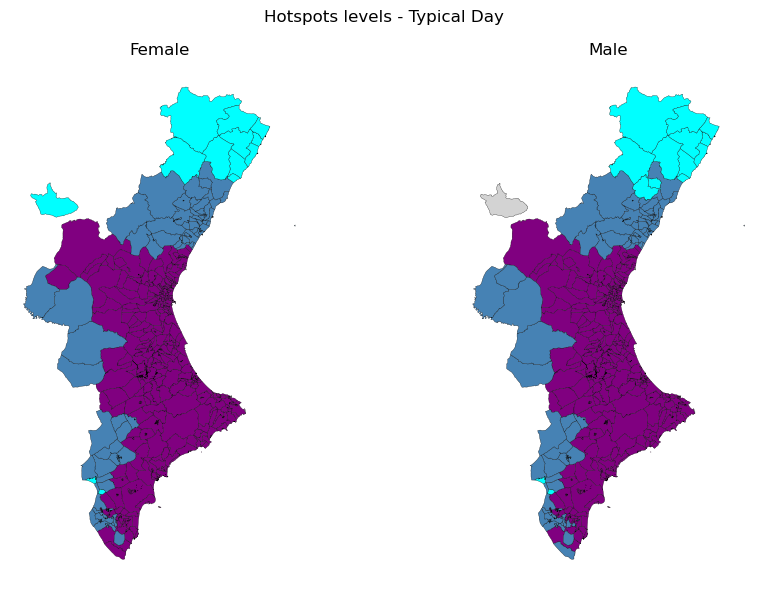

In [12]:
gdf_levels_T_M, results_T_M = iterative_lorenz_hotspots(gdf_T_M, n_iter=5)
gdf_levels_T_F, results_T_F = iterative_lorenz_hotspots(gdf_T_F, n_iter=5)
gdf_levels_P_M, results_P_M = iterative_lorenz_hotspots(gdf_P_M, n_iter=5)
gdf_levels_P_F, results_P_F = iterative_lorenz_hotspots(gdf_P_F, n_iter=5)

colors = {1: "purple", 2: "steelblue", 3: "cyan", 4: "gold", 5: "green"}

fig, ax = plt.subplots(1, 2, figsize=(10,6))
fig.suptitle("Hotspots levels - Typical Day")

gdf_levels_T_F[gdf_levels_T_F["hotspot_level"] == 0].plot(
    ax=ax[0],
    color="lightgrey",
    edgecolor="black",
    linewidth=0.2,
    label="No hotspot"
)
for level, color in colors.items():
    subset = gdf_levels_T_F[gdf_levels_T_F["hotspot_level"] == level]

    if len(subset) > 0:
        subset.plot(
            ax=ax[0],
            color=color,
            edgecolor="black",
            linewidth=0.2,
            label=f"Hotspot nivel {level}"
        )

    ax[0].set_title("Female")
    ax[0].axis("off")


gdf_levels_T_M[gdf_levels_T_M["hotspot_level"] == 0].plot(
    ax=ax[1],
    color="lightgrey",
    edgecolor="black",
    linewidth=0.2,
    label="No hotspot"
)
for level, color in colors.items():
    subset = gdf_levels_T_M[gdf_levels_T_M["hotspot_level"] == level]

    if len(subset) > 0:
        subset.plot(
            ax=ax[1],
            color=color,
            edgecolor="black",
            linewidth=0.2,
            label=f"Hotspot nivel {level}"
        )

    ax[1].set_title("Male")
    ax[1].axis("off")

fig.tight_layout()

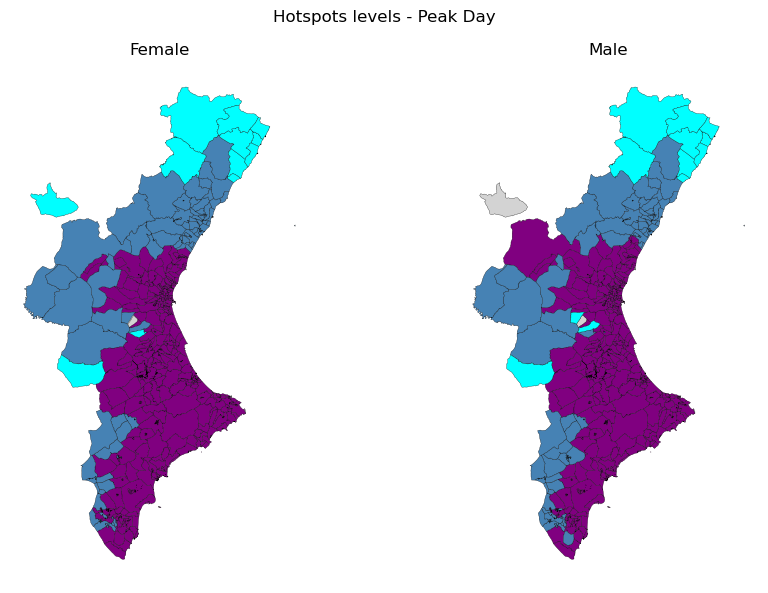

In [56]:
gdf_levels_P_M, results_P_M = iterative_lorenz_hotspots(gdf_P_M, comparable_cutoff=results_T_M)
gdf_levels_P_F, results_P_F = iterative_lorenz_hotspots(gdf_P_F, comparable_cutoff=results_T_F)

fig, ax = plt.subplots(1, 2, figsize=(10,6))
fig.suptitle("Hotspots levels - Peak Day")

gdf_levels_P_F[gdf_levels_P_F["hotspot_level"] == 0].plot(
    ax=ax[0],
    color="lightgrey",
    edgecolor="black",
    linewidth=0.2,
    label="No hotspot"
)
for level, color in colors.items():
    subset = gdf_levels_P_F[gdf_levels_P_F["hotspot_level"] == level]

    if len(subset) > 0:
        subset.plot(
            ax=ax[0],
            color=color,
            edgecolor="black",
            linewidth=0.2,
            label=f"Hotspot nivel {level}"
        )

    ax[0].set_title("Female")
    ax[0].axis("off")


gdf_levels_P_M[gdf_levels_P_M["hotspot_level"] == 0].plot(
    ax=ax[1],
    color="lightgrey",
    edgecolor="black",
    linewidth=0.2,
    label="No hotspot"
)
for level, color in colors.items():
    subset = gdf_levels_P_M[gdf_levels_P_M["hotspot_level"] == level]

    if len(subset) > 0:
        subset.plot(
            ax=ax[1],
            color=color,
            edgecolor="black",
            linewidth=0.2,
            label=f"Hotspot nivel {level}"
        )

    ax[1].set_title("Male")
    ax[1].axis("off")

fig.tight_layout()

In [ ]:
hotspot_dict_M = gdf_levels_T_M.set_index("ID")["hotspot_level"].to_dict()
hotspot_dict_F = gdf_levels_T_F.set_index("ID")["hotspot_level"].to_dict()

In [ ]:
trips_T_M = fdf_typical[fdf_typical.sexo == 'hombre']
trips_T_F = fdf_typical[fdf_typical.sexo == 'mujer']

trips_T_M["origin_level"] = trips_T_M["origin"].map(hotspot_dict_M)
trips_T_M["destination_level"] = trips_T_M["destination"].map(hotspot_dict_M)

trips_T_F["origin_level"] = trips_T_F["origin"].map(hotspot_dict_F)
trips_T_F["destination_level"] = trips_T_F["destination"].map(hotspot_dict_F)

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

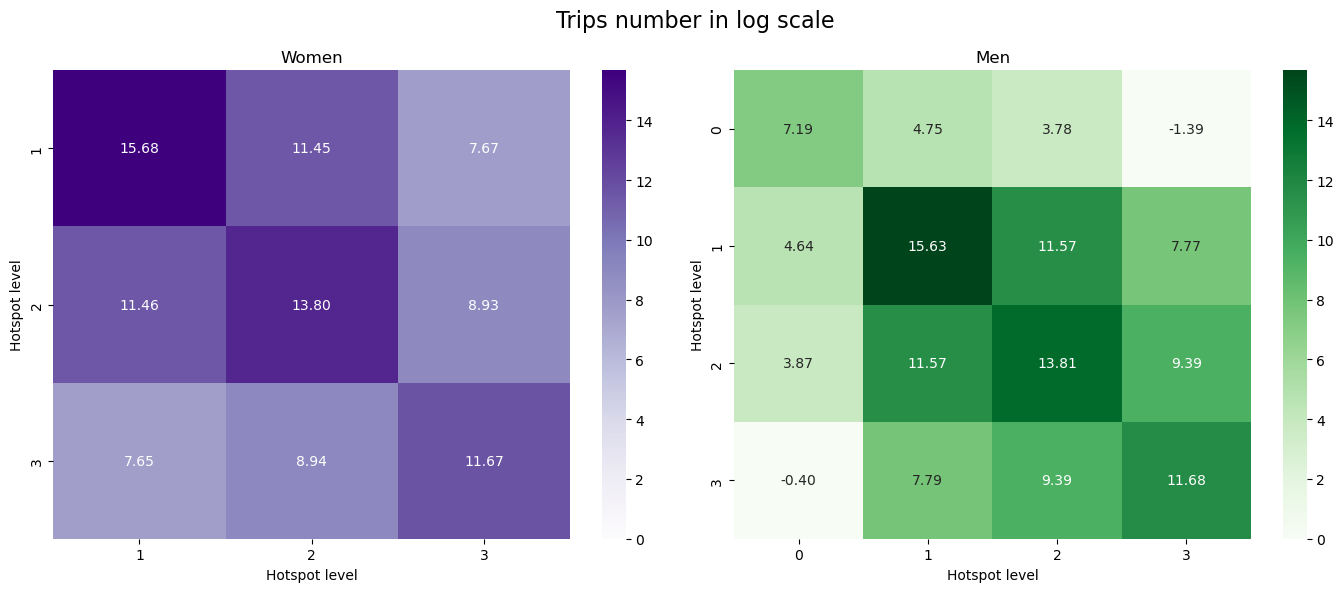

In [36]:
flows_levels_T_M = trips_T_M.groupby(["origin_level", "destination_level"], as_index=False).agg(flow=("flow", "sum"))
flows_levels_T_F = trips_T_F.groupby(["origin_level", "destination_level"], as_index=False).agg(flow=("flow", "sum"))

men_matrix = flows_levels_T_M.pivot(index="origin_level", columns="destination_level", values="flow")
women_matrix = flows_levels_T_F.pivot(index="origin_level", columns="destination_level", values="flow")
men_matrix = np.log(men_matrix)
women_matrix = np.log(women_matrix)

#  Compartir la misma escala de colores
vmax = max(men_matrix.values.max(), women_matrix.values.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    men_matrix,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=vmax,
    ax=axes[1]
)

axes[1].set_title("Men")
axes[1].set_xlabel("Hotspot level")
axes[1].set_ylabel("Hotspot level")

sns.heatmap(
    women_matrix,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    vmin=0,
    vmax=vmax,
    ax=axes[0]
)

axes[0].set_title("Women")
axes[0].set_xlabel("Hotspot level")
axes[0].set_ylabel("Hotspot level")

plt.suptitle("Trips number in log scale", fontsize=16)
plt.tight_layout()
plt.show()

In [38]:
trips_P_M = fdf_peak[fdf_peak.sexo == 'hombre']
trips_P_F = fdf_peak[fdf_peak.sexo == 'mujer']

trips_P_M["origin_level"] = trips_P_M["origin"].map(hotspot_dict_M)
trips_P_M["destination_level"] = trips_P_M["destination"].map(hotspot_dict_M)

trips_P_F["origin_level"] = trips_P_F["origin"].map(hotspot_dict_F)
trips_P_F["destination_level"] = trips_P_F["destination"].map(hotspot_dict_F)

flows_levels_P_M = trips_P_M.groupby(["origin_level", "destination_level"], as_index=False).agg(flow=("flow", "sum"))
flows_levels_P_F = trips_P_F.groupby(["origin_level", "destination_level"], as_index=False).agg(flow=("flow", "sum"))

men_matrix = flows_levels_P_M.pivot(index="origin_level", columns="destination_level", values="flow").fillna(0)
women_matrix = flows_levels_P_F.pivot(index="origin_level", columns="destination_level", values="flow").fillna(0)

men_matrix = np.log1p(men_matrix)
women_matrix = np.log1p(women_matrix)

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

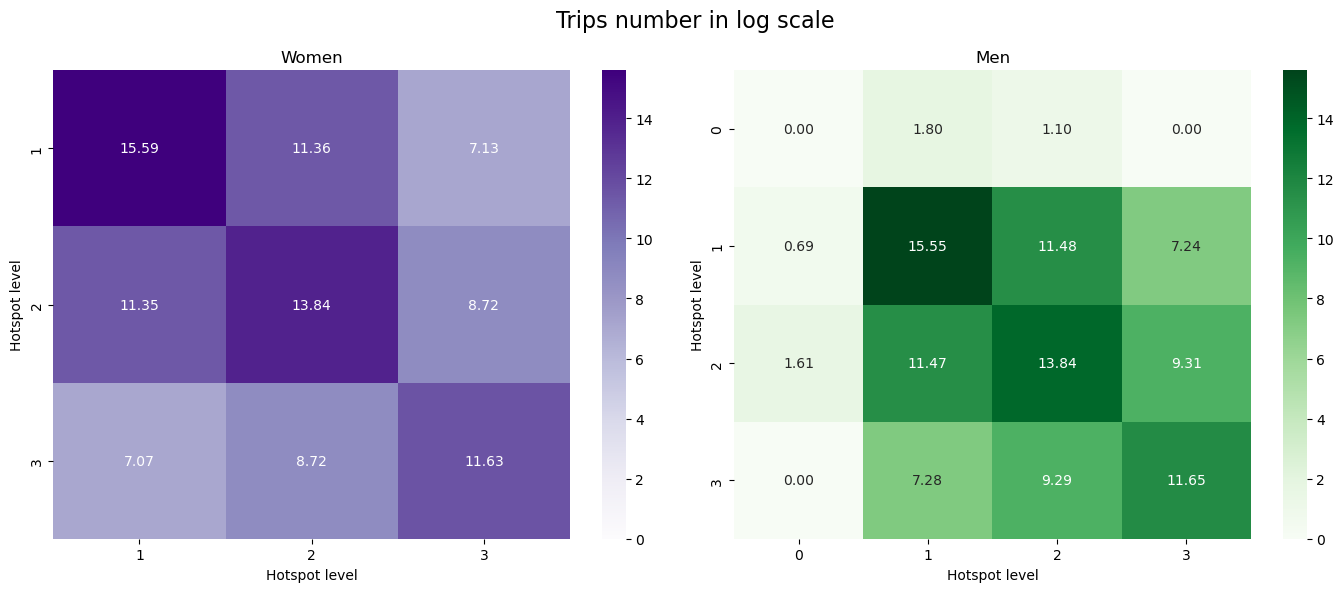

In [39]:
#  Compartir la misma escala de colores
vmax = max(men_matrix.values.max(), women_matrix.values.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    men_matrix,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=vmax,
    ax=axes[1]
)

axes[1].set_title("Men")
axes[1].set_xlabel("Hotspot level")
axes[1].set_ylabel("Hotspot level")

sns.heatmap(
    women_matrix,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    vmin=0,
    vmax=vmax,
    ax=axes[0]
)

axes[0].set_title("Women")
axes[0].set_xlabel("Hotspot level")
axes[0].set_ylabel("Hotspot level")

plt.suptitle("Trips number in log scale", fontsize=16)
plt.tight_layout()
plt.show()

### Closeness hotspots with deciles

In [ ]:
global_typical = daily_closeness_glob.set_index('day').loc[typical_days].mean().sort_index()
global_typical_df = pd.DataFrame(global_typical, columns=['closeness']).reset_index(names='area')
global_typical_df['area'] = global_typical_df['area'].map(dict_SC_inv)

outgoing_T_glob, incoming_T_glob, total_T_glob = trips_counting(fdf_typical.groupby(['origin', 'destination'], as_index=False).agg(flow=("flow", "sum")))
global_typical_df['flow'] = global_typical_df['area'].map(total_T_glob)
global_typical_df['closeness_norm'] = global_typical_df['closeness'].div(global_typical_df['flow'].sum())
global_typical_df['level'] = pd.qcut(global_typical_df['closeness_norm'], q=10, labels=range(1,11))
global_typical_df['level'] = global_typical_df['level'].astype(int)

gdf_global_typ = gdf_SC.merge(global_typical_df, left_on="ID", right_on="area", how='left')
gdf_global_typ

,ID,geometry,area,closeness,flow,closeness_norm,level
0,03002_AM,"POLYGON ((711408.929 4253041.896, 711515.519 4...",03002_AM,126.515060,34305.83875,0.000004,5
1,03005_AM,"POLYGON ((689777.057 4230276.017, 689796.584 4...",03005_AM,116.604309,70004.16725,0.000004,4
2,03006_AM,"MULTIPOLYGON (((763745.474 4294588.096, 763792...",03006_AM,129.219940,15558.39000,0.000004,5
3,0300901,"POLYGON ((719753.18 4286248.848, 719761.478 42...",0300901,140.884016,35868.90050,0.000005,6
4,0300902,"POLYGON ((719798.246 4285276.544, 719753.225 4...",0300902,142.613357,57581.38175,0.000005,6
...,...,...,...,...,...,...,...
412,46257,"POLYGON ((715637.008 4325985.576, 715622.951 4...",46257,160.601337,35725.21375,0.000005,9
413,46258,"POLYGON ((689532.301 4396594.499, 689721.301 4...",46258,117.657485,7337.89725,0.000004,4
414,46260,"POLYGON ((726718.38 4379175.102, 726672.453 43...",46260,142.386729,19549.88075,0.000005,6
415,46261_AM,"POLYGON ((699498.267 4348913.417, 699279.263 4...",46261_AM,138.253205,23906.71425,0.000005,6


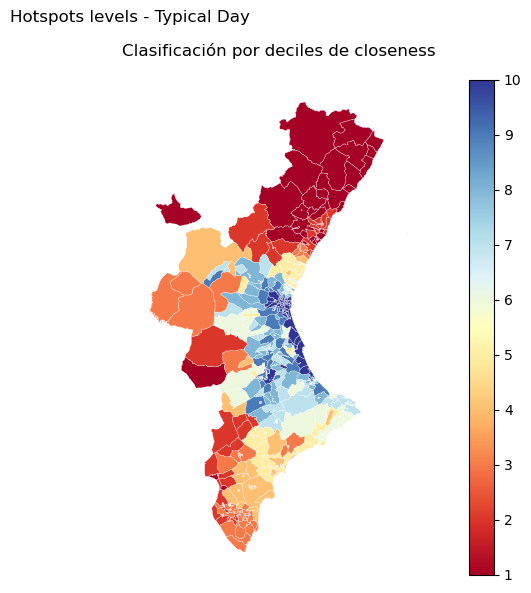

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
fig.suptitle("Hotspots levels - Typical Day")

gdf_global_typ.plot(
    column="level",
    cmap="RdYlBu",      # o "YlOrRd", "plasma", "RdYlBu", etc.
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.2
)

ax.set_axis_off()
ax.set_title("Clasificación por deciles de closeness")

plt.tight_layout()
plt.show()

In [35]:
hotspot_dict = gdf_global_typ.set_index("ID")["level"].to_dict()

trips_T_M = fdf_typical[fdf_typical.sexo == 'hombre']
trips_T_F = fdf_typical[fdf_typical.sexo == 'mujer']

trips_T_M["origin_level"] = trips_T_M["origin"].map(hotspot_dict)
trips_T_M["destination_level"] = trips_T_M["destination"].map(hotspot_dict)

trips_T_F["origin_level"] = trips_T_F["origin"].map(hotspot_dict)
trips_T_F["destination_level"] = trips_T_F["destination"].map(hotspot_dict)

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

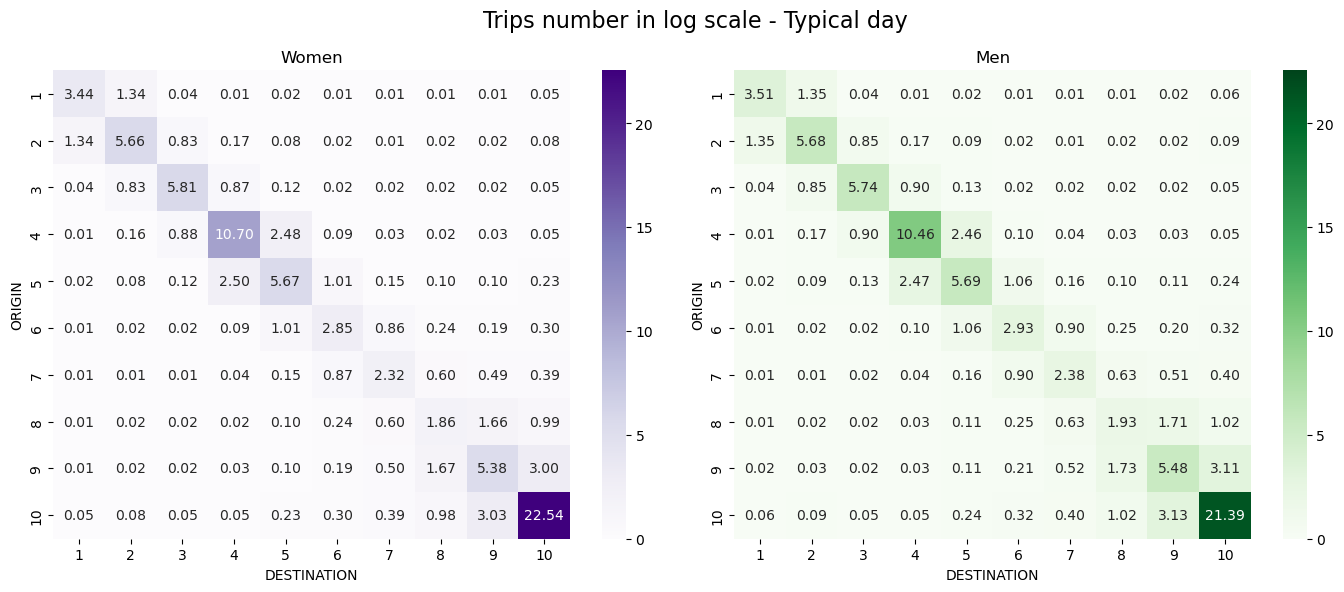

In [51]:
flows_levels_T_M = trips_T_M.groupby(["origin_level", "destination_level"], as_index=False).agg(flow=("flow", "sum"))
flows_levels_T_F = trips_T_F.groupby(["origin_level", "destination_level"], as_index=False).agg(flow=("flow", "sum"))

men_matrix = flows_levels_T_M.pivot(index="origin_level", columns="destination_level", values="flow")
women_matrix = flows_levels_T_F.pivot(index="origin_level", columns="destination_level", values="flow")

#  Apply log-scale to the matrix if it is needed
#men_matrix = np.log(men_matrix)
#women_matrix = np.log(women_matrix)

#  Write the matrix with porcentages
men_matrix = men_matrix / men_matrix.values.sum() * 100
women_matrix = women_matrix / women_matrix.values.sum() * 100

#  Share same colors-code
vmax = max(men_matrix.values.max(), women_matrix.values.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    men_matrix,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=vmax,
    ax=axes[1]
)

axes[1].set_title("Men")
axes[1].set_xlabel("DESTINATION")
axes[1].set_ylabel("ORIGIN")

sns.heatmap(
    women_matrix,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    vmin=0,
    vmax=vmax,
    ax=axes[0]
)

axes[0].set_title("Women")
axes[0].set_xlabel("DESTINATION")
axes[0].set_ylabel("ORIGIN")

plt.suptitle("Trips number in log scale - Typical day", fontsize=16)
plt.tight_layout()
plt.show()

In [54]:
trips_P_M = fdf_peak[fdf_peak.sexo == 'hombre']
trips_P_F = fdf_peak[fdf_peak.sexo == 'mujer']

trips_P_M["origin_level"] = trips_P_M["origin"].map(hotspot_dict)
trips_P_M["destination_level"] = trips_P_M["destination"].map(hotspot_dict)

trips_P_F["origin_level"] = trips_P_F["origin"].map(hotspot_dict)
trips_P_F["destination_level"] = trips_P_F["destination"].map(hotspot_dict)

flows_levels_P_M = trips_P_M.groupby(["origin_level", "destination_level"], as_index=False).agg(flow=("flow", "sum"))
flows_levels_P_F = trips_P_F.groupby(["origin_level", "destination_level"], as_index=False).agg(flow=("flow", "sum"))

men_matrix = flows_levels_P_M.pivot(index="origin_level", columns="destination_level", values="flow").fillna(0)
women_matrix = flows_levels_P_F.pivot(index="origin_level", columns="destination_level", values="flow").fillna(0)

#  Apply log-scale to the matrix if it is needed
#men_matrix = np.log1p(men_matrix)
#women_matrix = np.log1p(women_matrix)

#  Write the matrix with porcentages
men_matrix = men_matrix / men_matrix.values.sum() * 100
women_matrix = women_matrix / women_matrix.values.sum() * 100

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

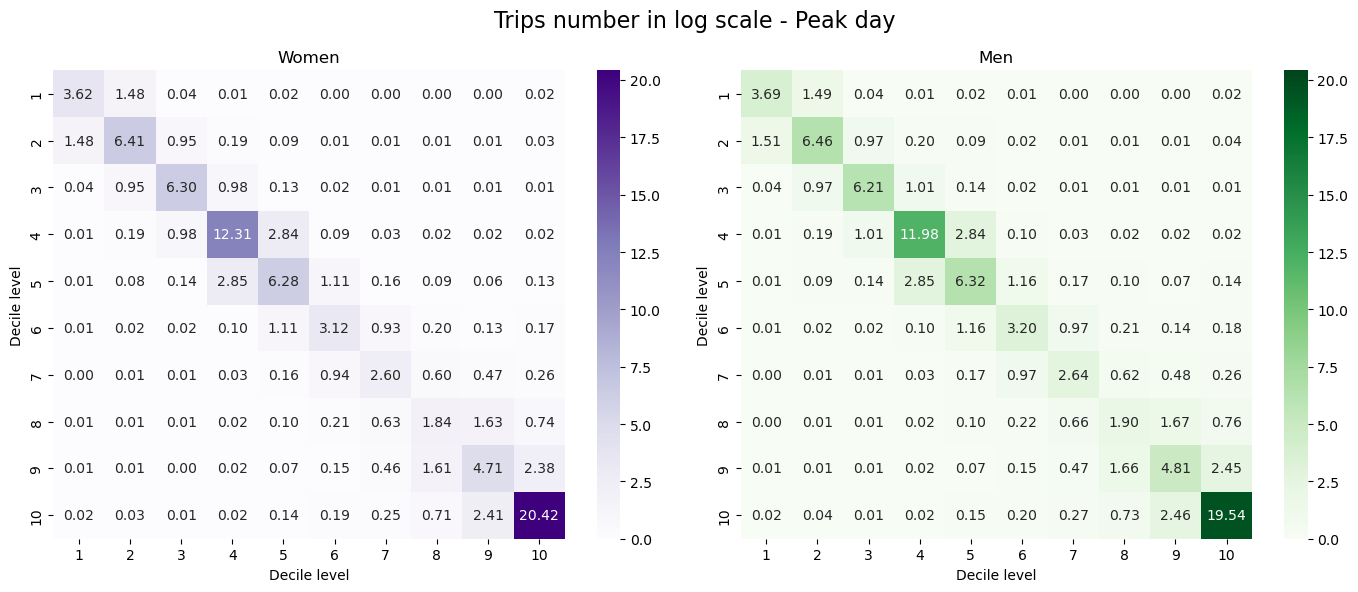

In [55]:
vmax = max(men_matrix.values.max(), women_matrix.values.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    men_matrix,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=vmax,
    ax=axes[1]
)

axes[1].set_title("Men")
axes[1].set_xlabel("Decile level")
axes[1].set_ylabel("Decile level")

sns.heatmap(
    women_matrix,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    vmin=0,
    vmax=vmax,
    ax=axes[0]
)

axes[0].set_title("Women")
axes[0].set_xlabel("Decile level")
axes[0].set_ylabel("Decile level")

plt.suptitle("Trips number in log scale - Peak day", fontsize=16)
plt.tight_layout()
plt.show()

### Entropy distribution

In [57]:
def local_entropy(df): 
    df["total_flow"] = df.groupby("origin")["flow"].transform("sum")
    df["p"] = df["flow"] / df["total_flow"]
    df["entropy"] = -df["p"] * np.log2(df["p"])

    entropy = df.groupby("origin", as_index=False).agg(H=("entropy", "sum"))

    # Normalized entropy
    degree = df.groupby("origin")["destination"].nunique().reset_index(name="k")
    entropy = entropy.merge(degree, on="origin")
    entropy["H_norm"] = np.where(
        entropy["k"] > 1,
        entropy["H"] / np.log2(entropy["k"]),
        0.0
    )

    return entropy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


<Axes: >

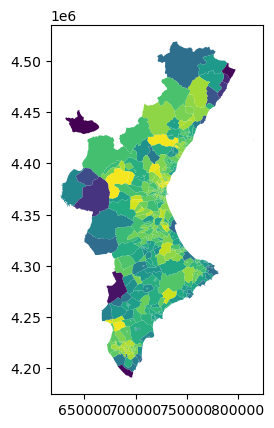

In [59]:
gdf_SC.merge(local_entropy(fdf_typical[fdf_typical.sexo == 'hombre']), left_on="ID", right_on="origin").plot(column='H_norm')